# AMI Deconvolutions


In [1]:
import jax
from jax import numpy as np
jax.config.update("jax_enable_x64", True)

import amigo
import dorito

import astropy

from optim_funcs import sgd, adam

# visualisation
import matplotlib.pyplot as plt
import matplotlib as mpl
import ehtplot
import scienceplots


In [2]:
# matplotlib parameters
plt.style.use(['science', 'bright', 'no-latex'])

%matplotlib inline
plt.rcParams["image.cmap"] = "inferno"
plt.rcParams["font.family"] = "serif"
plt.rcParams["image.origin"] = "lower"
plt.rcParams["figure.dpi"] = 300
plt.rcParams["font.size"] = 8
plt.rcParams["xtick.direction"] = "out"
plt.rcParams["ytick.direction"] = "out"

inferno = mpl.colormaps["inferno"]
viridis = mpl.colormaps["viridis"]
seismic = mpl.colormaps["seismic"]

inferno.set_bad("k", 0.5)
viridis.set_bad("k", 0.5)
seismic.set_bad("k", 0.5)

In [3]:
model_cache = "/Users/mcha5804/Library/CloudStorage/OneDrive-TheUniversityofSydney(Students)/PyCharm/jwst/io/arrays/"
init_state_cache = model_cache + "init_states/"
gif_dir = "/Users/mcha5804/Library/CloudStorage/OneDrive-TheUniversityofSydney(Students)/PyCharm/jwst/io/gifs/"
reconstructions_dir = "/Users/mcha5804/Library/CloudStorage/OneDrive-TheUniversityofSydney(Students)/PyCharm/jwst/io/reconstructions/"

final_states = [
    np.load(model_cache + f"new_top_models 2/state_{i}.npy", allow_pickle=True)[()]
    # for i in ["36", "63", "112", "120"]
    for i in ["84", "125"]
    ]

final_state = final_states[0]

# final_state = np.load(model_cache + "odes/ode_state.npy", allow_pickle=True).item()

width = final_state.pop('width')
depth = final_state.pop('depth')
_ = final_state.pop("lr")
_ = final_state.pop("rand_size")

EXP_TYPE = "NIS_AMI"
FILTERS = ["F480M", "F430M", "F380M"] #, "F277W"]

# Bind file path, type and exposure type
file_fn = lambda data_path, filters=FILTERS, **kwargs: amigo.files.get_files(
    # "/Users/mcha5804/JWST/ERS1373/calgrps/",
    data_path,
    "calslope",
    EXP_TYPE=EXP_TYPE,
    FILTER=filters,
    **kwargs,
)


In [4]:
# import zodiax as zdx
# import dLux.utils as dlu
# from amigo.ode_models import ODESolver, ODEFunc
# from amigo.ramp_models import Ramp
# import jaxlib as jxl
# from amigo.misc import calc_laplacian
# import equinox as eqx
# from jax import random as jr, tree as jtu, vmap

# class ODERamp(ODESolver):
#     psf_downsample: int = eqx.field(static=True)
#     ramp_downsample: int = eqx.field(static=True)
#     norm: int = eqx.field(static=True)

#     def __init__(self, ODE, norm=2**15, psf_downsample=2, ramp_downsample=2):
#         super().__init__(ODE)
#         self.norm = int(norm)
#         self.psf_downsample = psf_downsample
#         self.ramp_downsample = ramp_downsample

#     def downsample_ramp(self, ramp, n):
#         return vmap(lambda x, n: dlu.downsample(x, n, mean=False), (0, None))(ramp, n)

#     def solve(self, illuminance, ngroups):
#         ts = (np.arange(0, ngroups) + 1) / ngroups
#         y0 = np.zeros_like(illuminance)
#         args = illuminance
#         return self.solve_fn(y0, args, ts)

#     def predict_ramp(self, illuminance, ngroups):
#         illuminance /= self.norm
#         if self.psf_downsample is not None:
#             illuminance = dlu.downsample(illuminance, self.psf_downsample, mean=False)
#         ramp = self.solve(illuminance, ngroups).ys

#         if self.ramp_downsample is not None:
#             ramp = self.downsample_ramp(ramp, self.ramp_downsample)
#         return self.norm * ramp

#     def predict_slopes(self, illuminance, ngroups):
#         ramp = self.predict_ramp(illuminance, ngroups)
#         return np.diff(ramp, axis=0)

#     def apply(self, psf, flux, exposure, oversample):
#         ramp = self.predict_ramp(psf.data * flux, exposure.ngroups)
#         return Ramp(ramp, psf.pixel_scale)


# class NNWrapper(zdx.Base):
#     values: np.ndarray
#     tree_def: jxl.xla_extension.pytree.PyTreeDef
#     shapes: list[tuple[int]] = eqx.field(static=True)
#     sizes: list[int] = eqx.field(static=True)
#     starts: list[int] = eqx.field(static=True)

#     def __init__(self, layers):
#         leaves, tree_def = jtu.flatten(layers)
#         self.values = np.concatenate([val.flatten() for val in leaves])
#         self.shapes = [v.shape for v in leaves]
#         self.sizes = [int(v.size) for v in leaves]
#         self.starts = [int(i) for i in np.cumsum(np.array([0] + self.sizes))]
#         self.tree_def = tree_def

#     @property
#     def layers(self):
#         leaves = [
#             jax.lax.dynamic_slice(self.values, (start,), (size,)).reshape(shape)
#             for start, size, shape in zip(self.starts, self.sizes, self.shapes)
#         ]
#         return jtu.unflatten(self.tree_def, leaves)

#     def __call__(self, x):
#         layers = self.layers
#         if x.ndim == 2:
#             x = x[None, ...]
#         for layer in layers[:-1]:
#             x = jax.nn.relu(layer(x))
#         out = np.squeeze(layers[-1](x))
#         return out

#     @property
#     def size(self):
#         return np.sum(np.array(jtu.leaves(jtu.map(lambda x: x.size, self.layers))))


# class NeuralODE(zdx.Base, ODEFunc):
#     network: None

#     def __init__(self, network):
#         self.network = network

#     def __getattr__(self, name):
#         if hasattr(self.network, name):
#             return getattr(self.network, name)
#         raise AttributeError(f"Attribute {name} not found in NeuralODE or network.")

#     def eval_network(self, t, charge, illuminance):
#         laplacian = calc_laplacian(charge)
#         xgrads, ygrads = np.gradient(charge)
#         x = np.array([t * illuminance, laplacian, charge, xgrads, ygrads])
#         return self.network(x)

#     def derivative(self, t, charge, illuminance):
#         return illuminance + self.eval_network(t, charge, illuminance)


# def layer_fn(in_channels, out_channels, **kwargs):
#     return lambda key: eqx.nn.Conv2d(
#         in_channels=in_channels,
#         out_channels=out_channels,
#         kernel_size=3,
#         padding=(1, 1),
#         key=key,
#         **kwargs,
#     )


# layer_fns = [
#     layer_fn(5, 32, use_bias=False),
#     layer_fn(32, 16, use_bias=False),
#     layer_fn(16, 1, use_bias=False),
# ]

# layers = []
# keys = jr.split(jr.PRNGKey(1), (len(layer_fns),))
# for i, layer_fn in enumerate(layer_fns):
#     layer = layer_fn(keys[i])
#     if layer.use_bias:
#         layer = eqx.tree_at(lambda layer: layer.bias, layer, layer.bias * 1e-3)
#     layers.append(layer)


# # Define the ODE model
# ODE = NeuralODE(NNWrapper(layers))
# ode_model = ODERamp(ODE, psf_downsample=4, ramp_downsample=1)
# # ode_model = ode_model.multiply("values", 1e0)
# # model = model.set("ramp", ode_model)
# # print(ode_model.values)

# IO

In [13]:
io_path = "/Users/mcha5804/JWST/IO/calslope/"

io_files = file_fn(io_path)

nsci = 1; ncal = 2

io_sci_files = []; io_cal_files = []
io_rolls = {}

for file in io_files:

    # manual bad pixel correction
    file["BADPIX"].data[58, 67] = 1
    file["BADPIX"].data[:, :3] = 1
    file["BADPIX"].data[:, -3:] = 1
    file["BADPIX"].data[:3, :] = 1
    file["BADPIX"].data[-3:, :] = 1

    filename = file[0].header["FILENAME"].replace("_nis_calslope.fits", "")
    io_rolls[filename] = dorito.plotting.calc_parang(file)

    if file[0].header["TARGPROP"] == "IO":
        io_sci_files.append(file)
    elif file[0].header["TARGPROP"] == "PSFCAL.2022A-HD2236-K6":
        file[0].header["TARGPROP"] = "HD 2236"
        io_cal_files.append(file)
    else:
        print(f"Unkown target: {file[0].header['TARGPROP']}")

io_cal_files = io_cal_files[4-ncal:]
io_sci_files = io_sci_files[:nsci]
dorito.misc.truncate_files(io_sci_files, 18, 45)


for f in io_sci_files:
    print(f[0].header["TARGPROP"], f[0].header["NGROUPS"], f["SLOPE"].data.shape)

for f in io_cal_files:
    print(f[0].header["TARGPROP"], f[0].header["NGROUPS"], f["SLOPE"].data.shape)

IO 45 (17, 80, 80)
HD 2236 12 (11, 80, 80)
HD 2236 12 (11, 80, 80)


In [19]:
io_model, io_params, io_exposures = build_resolved_model(
    io_cal_files,
    io_sci_files,
    final_state,
    ramp_model=ode_model,
    # width=width,
    # depth=depth,
    # separate_exposures=True,
    # log_dist_prior=np.log10(dorito.build_model.softcirc_prior()),
)

# io_exposures = [*io_cal_exposures, *io_sci_exposures]
io_model = io_model.set("FF", np.ones_like(io_model.FF))

io_init_state = np.load(init_state_cache + "io/io_setup.npy", allow_pickle=True)[()]

for p in [
    # "positions",
    # "fluxes",
    "aberrations"
    ]:
    io_params[p] = io_init_state[p]

# io_model = io_model.set("params", io_params)
# io_model = io_model.set("ramp", ode_model)  # TODO want this?
# io_model = amigo.misc.populate_from_state(io_model, final_state)



In [31]:
# io_fisher_params = list(io_params.keys())

io_fisher_params = [
    "positions",
    "fluxes",
    "aberrations",
    # "one_on_fs",
    "log_distribution",
    # "spectral_coeffs",
]

# rampless_model = cal_model.set("ramp", None)
io_fishers = amigo.fisher.calc_fishers(
    io_model.set("ramp", None),
    # io_cal_exposures,
    io_exposures,
    io_fisher_params,
    overwrite=True,
    recalculate=False,
    )

  0%|          | 0/3 [00:00<?, ?it/s]

Could not calculate fisher for log_distribution - 01373_023_02_03_2
Could not calculate fisher for log_distribution - 01373_023_02_03_1


In [32]:
n_epoch = 40

config = {
    "positions": sgd(5e-1, 0), # (learning_rate, start epoch)
    "fluxes": sgd(1e-1, 2),
    "aberrations": sgd(4e-2, 4),

    # "positions": sgd(2e-1, 0),
    # "fluxes": sgd(0.5e-1, 0),
    # "aberrations": sgd(2e-2, 0),

    # "one_on_fs": sgd(1e2, 6),
    "log_distribution": adam(2e-1, 8),#, (10, 0.25), b1=0.7),
    # "log_distribution": adam(2e-1, 3),#, (10, 0.25), b1=0.7),
    # "source_spectrum.coefficients": sgd(1e-1, 5),
}

io_final_model, io_losses, _, io_histories = amigo.fitting.optimise(
    io_model,
    io_exposures,
    fishers=io_fishers,
    optimisers=config,
    epochs=n_epoch,
    print_grads=False,
)

  0%|          | 0/40 [00:00<?, ?it/s]

Grad Batch fn compiling...
Compiling update function
Grad Batch fn compiling...
Grad Batch fn compiling...
Compiling update function
Compile Time: 0:00:32
Initial Loss: 5,187.55
Est time per epoch:  0:00:15
Est run time:  0:10:24
Full Time: 0:10:38
Final Loss: 62.94


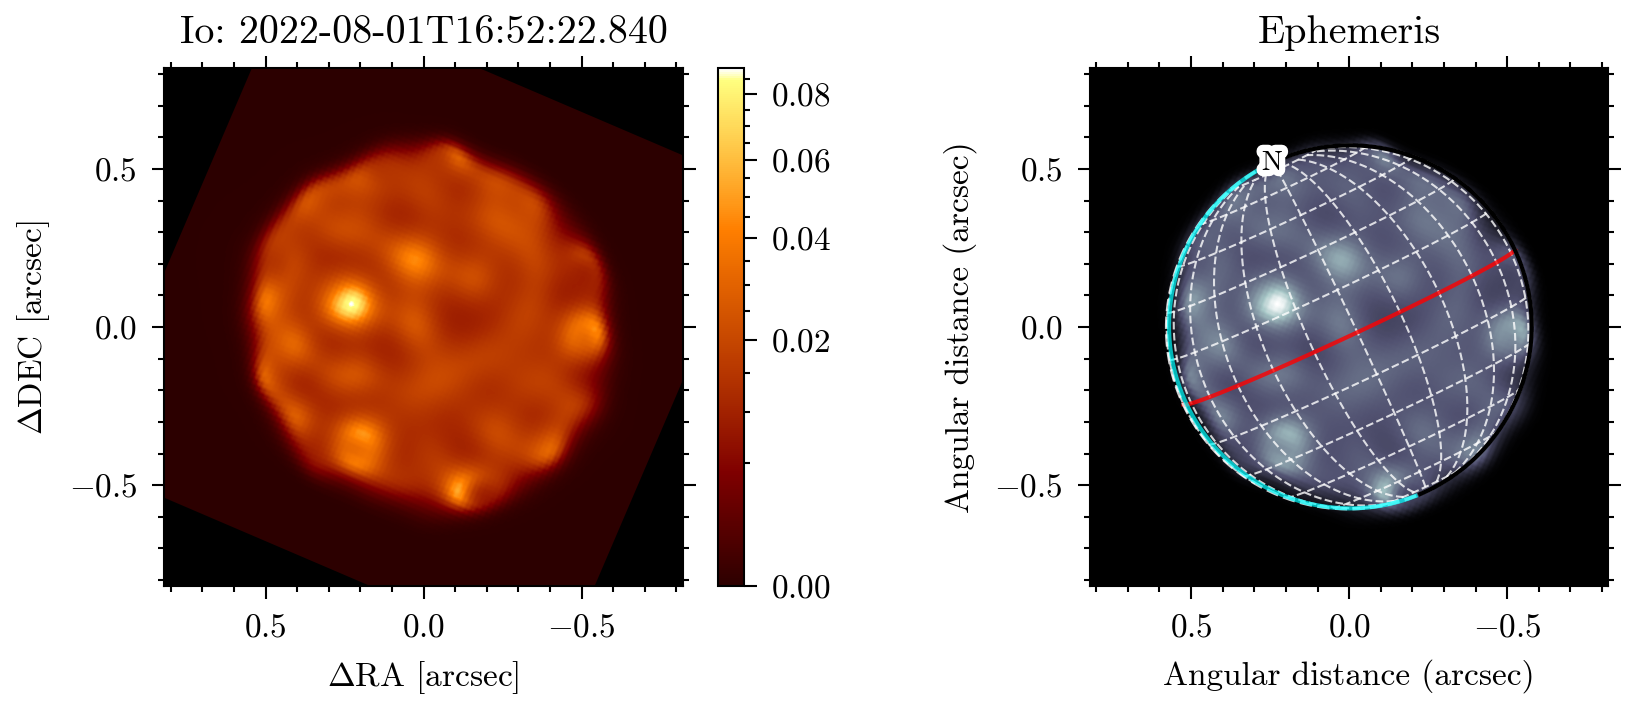

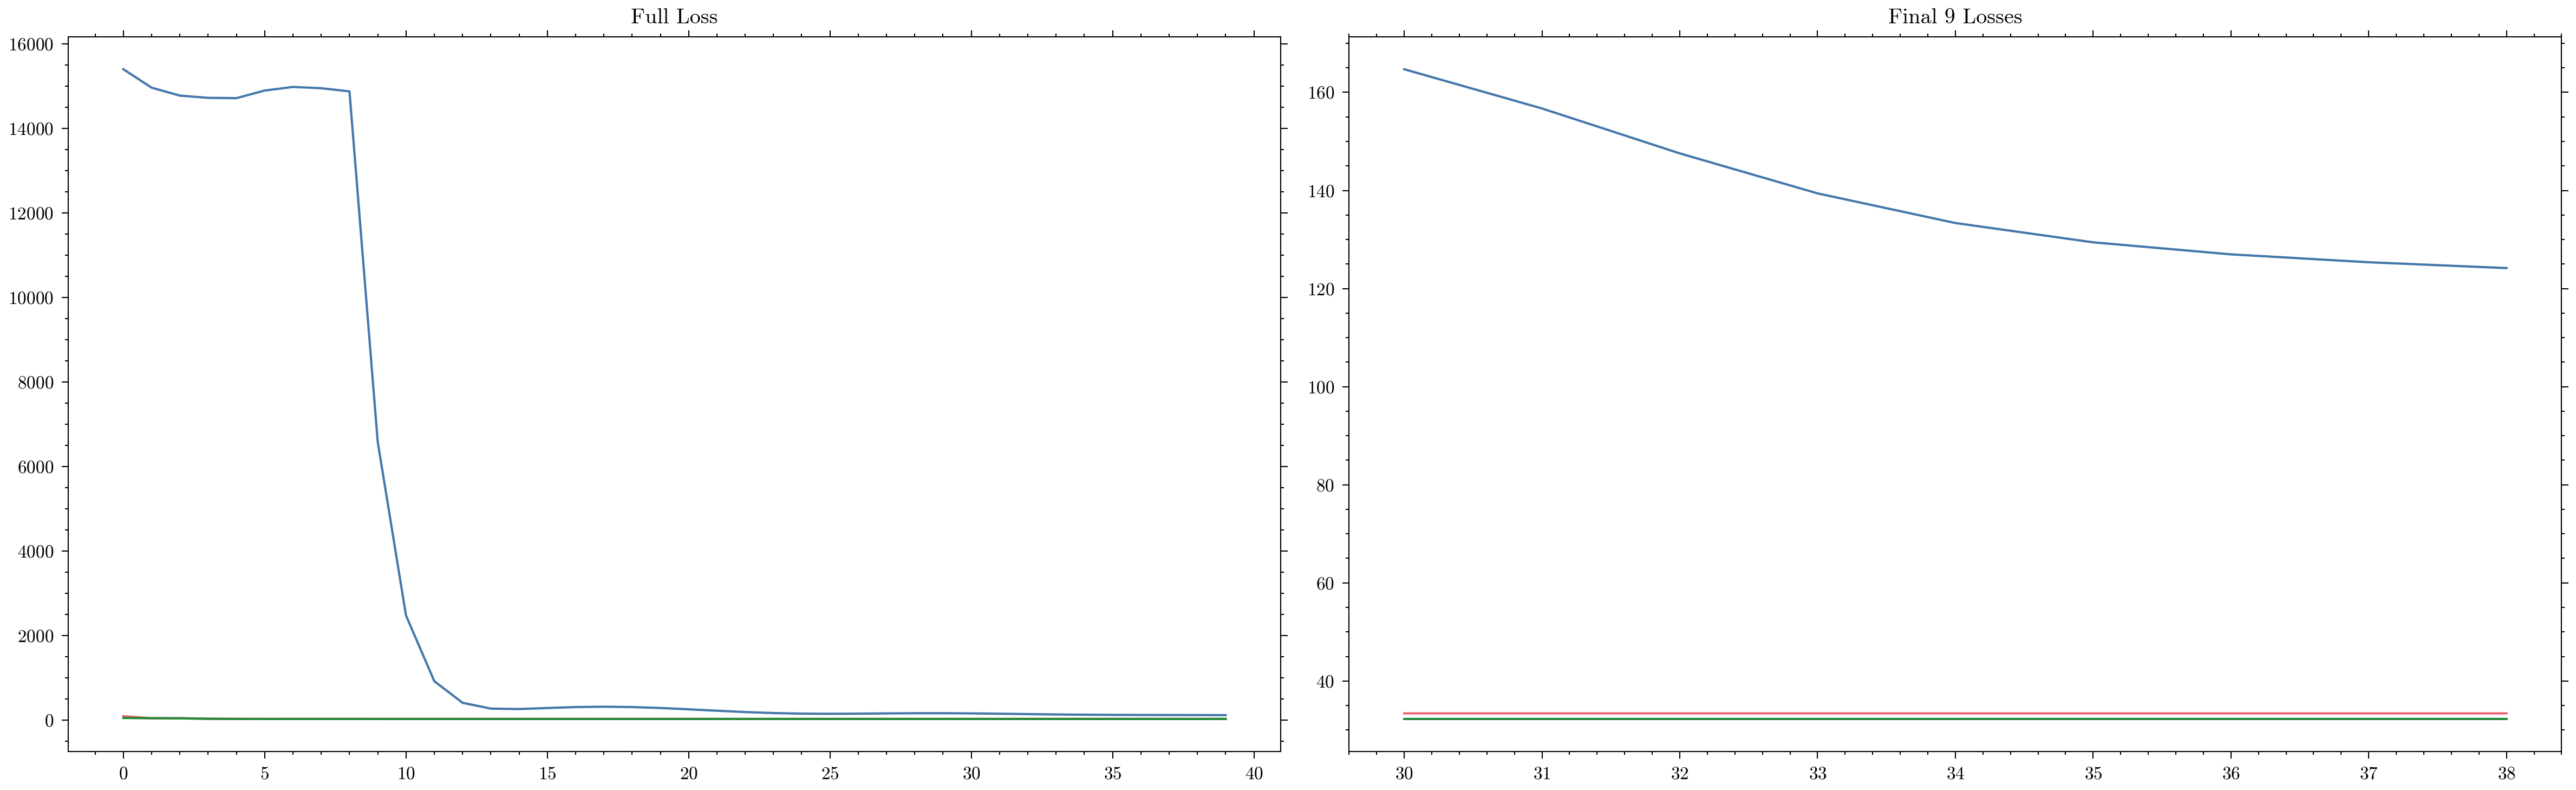

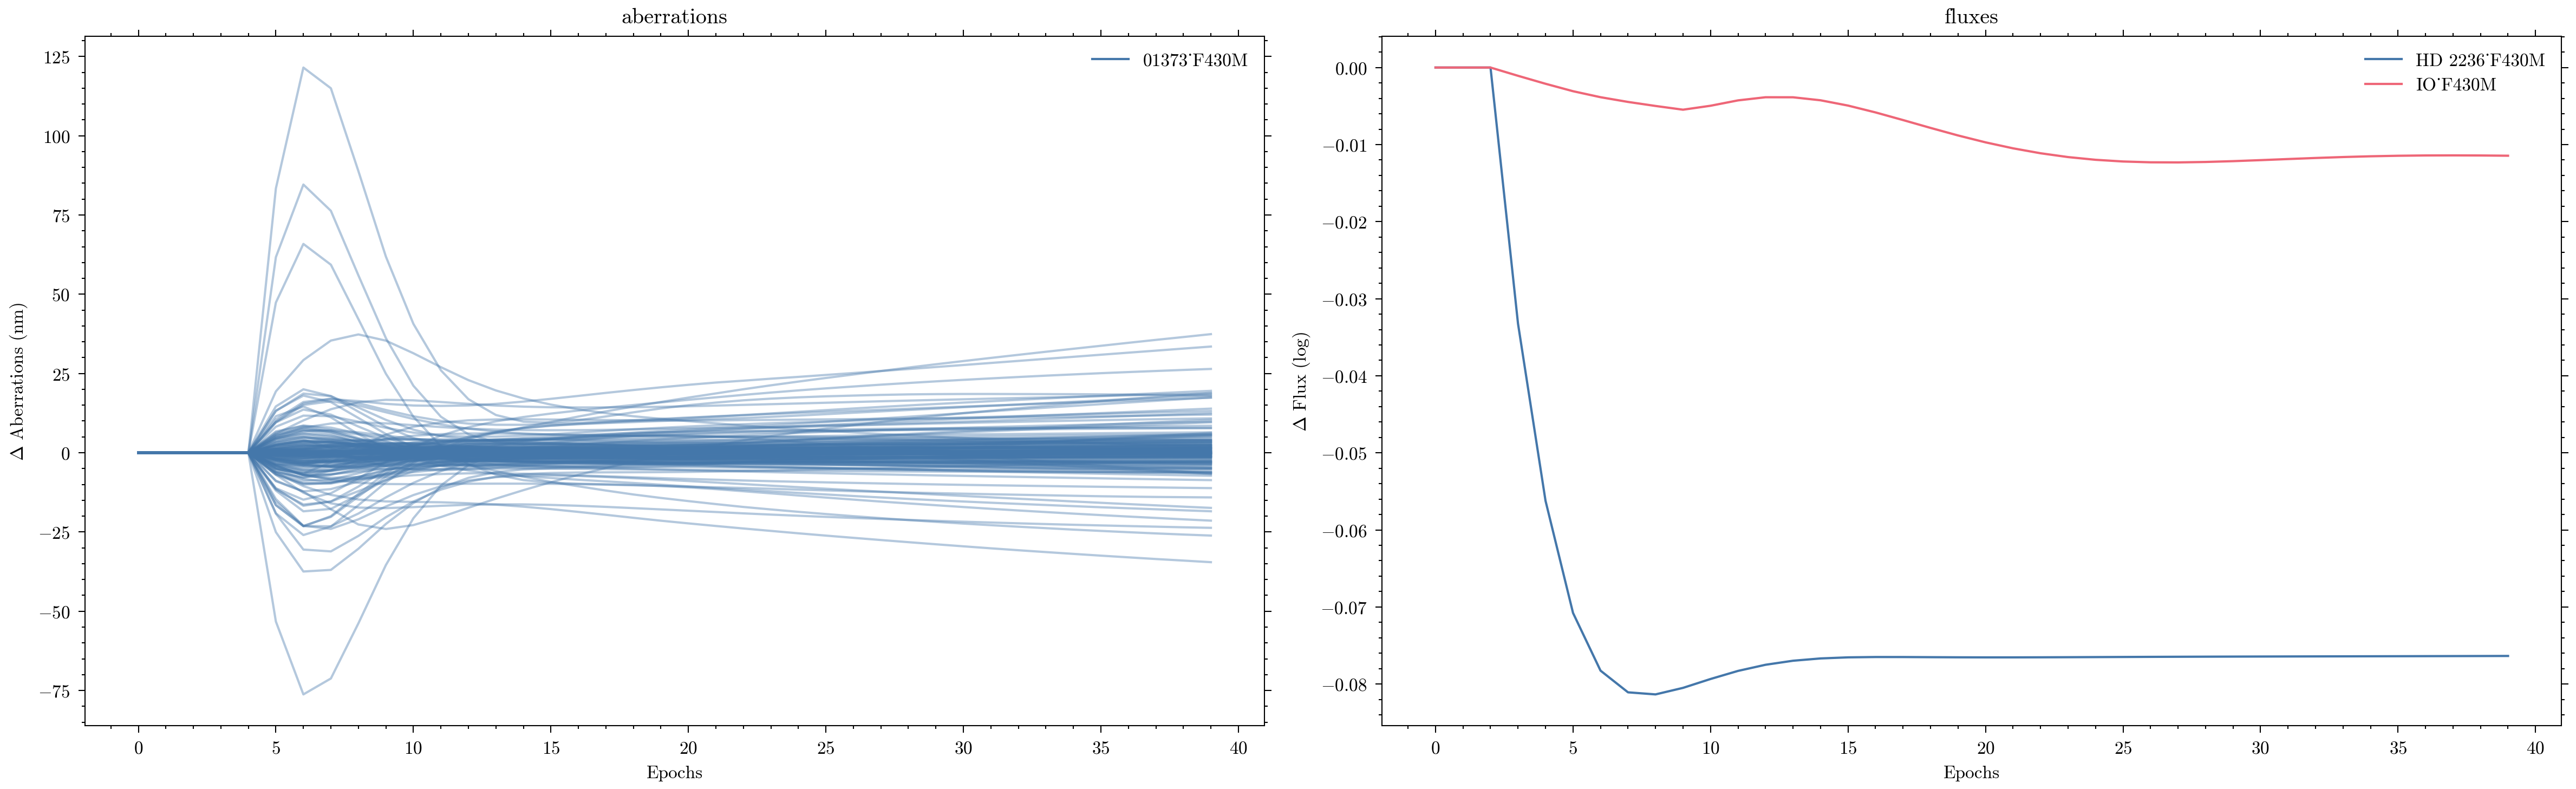

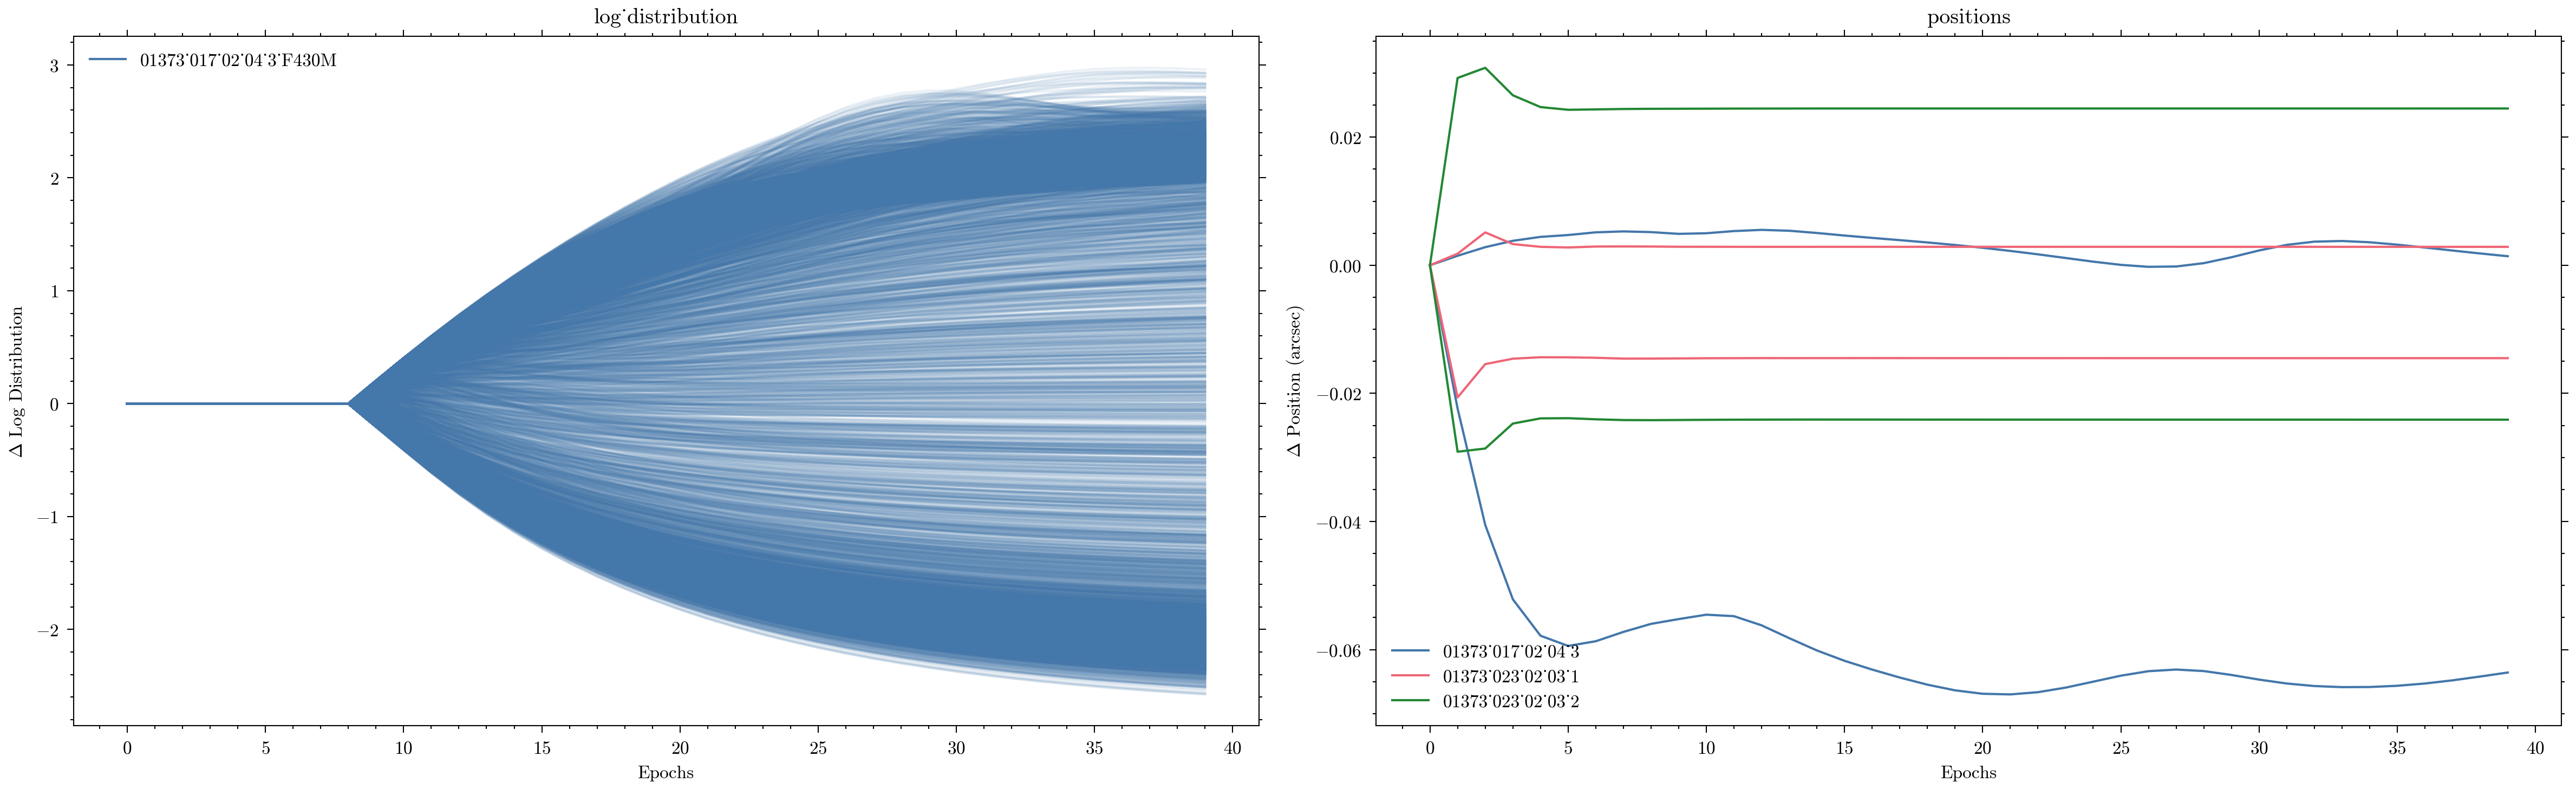

File 01373_023_02_03_2
Star HD 2236
Filter F430M
nints 8
ngroups 12



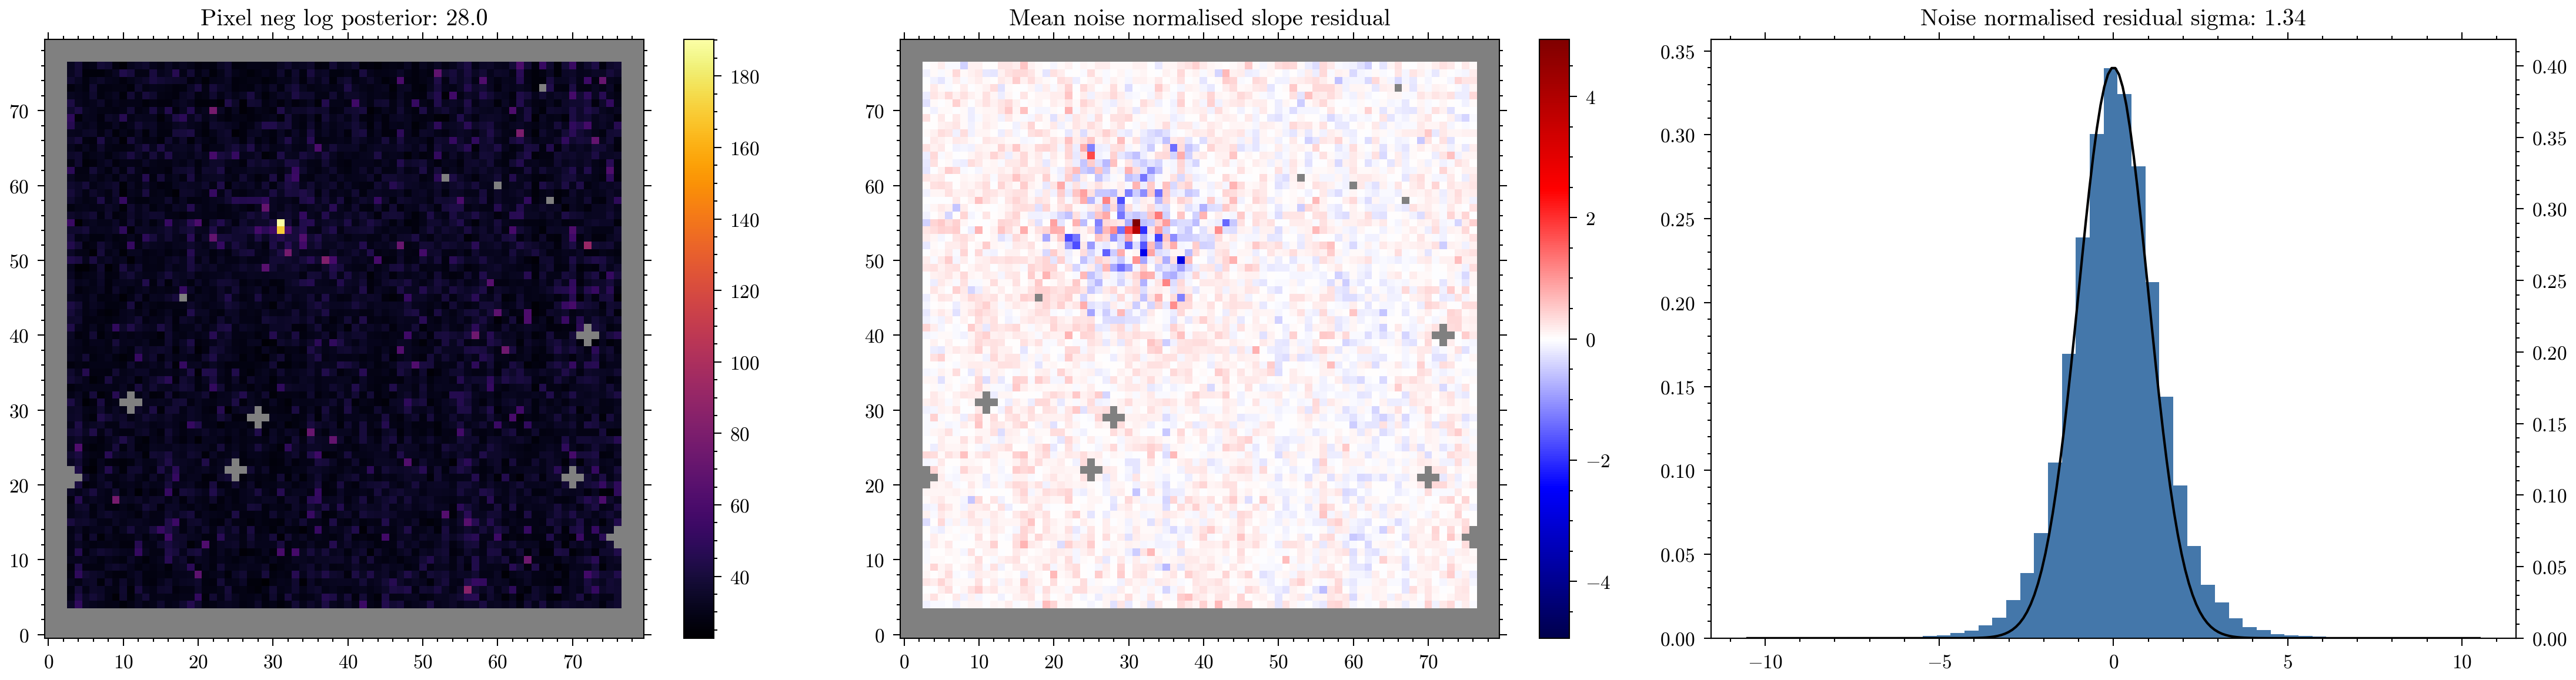

File 01373_023_02_03_1
Star HD 2236
Filter F430M
nints 8
ngroups 12



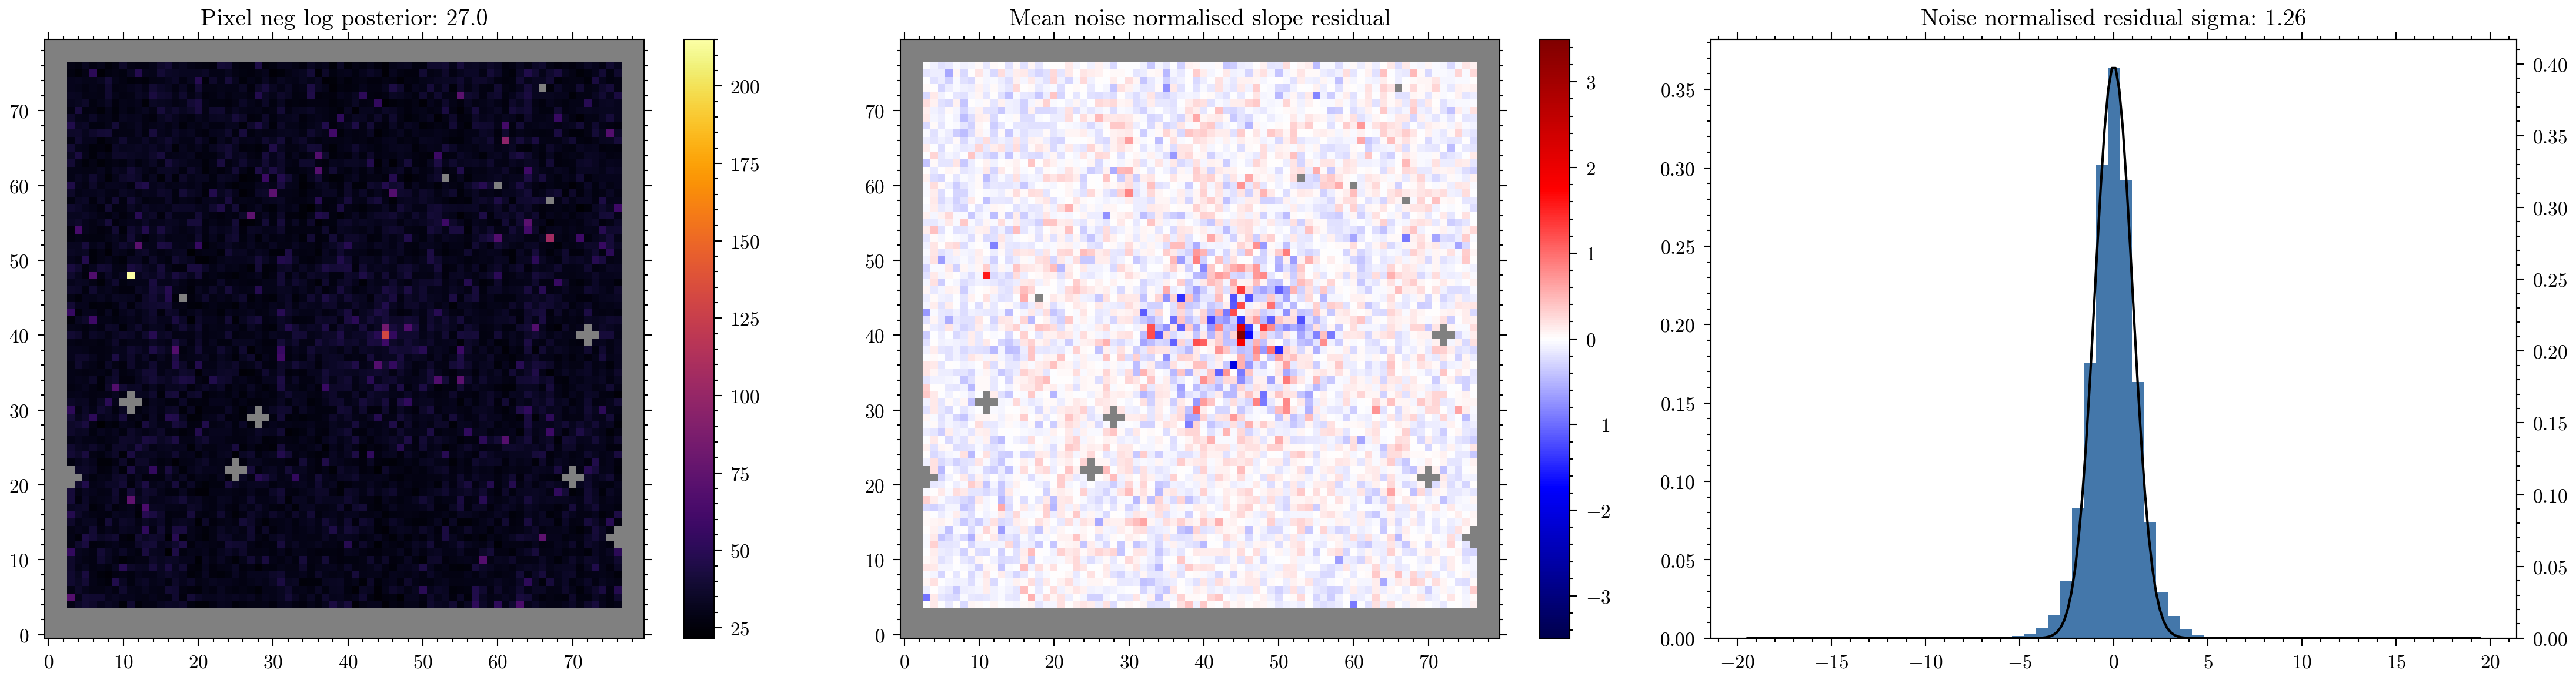

File 01373_017_02_04_3
Star IO
Filter F430M
nints 100
ngroups 18



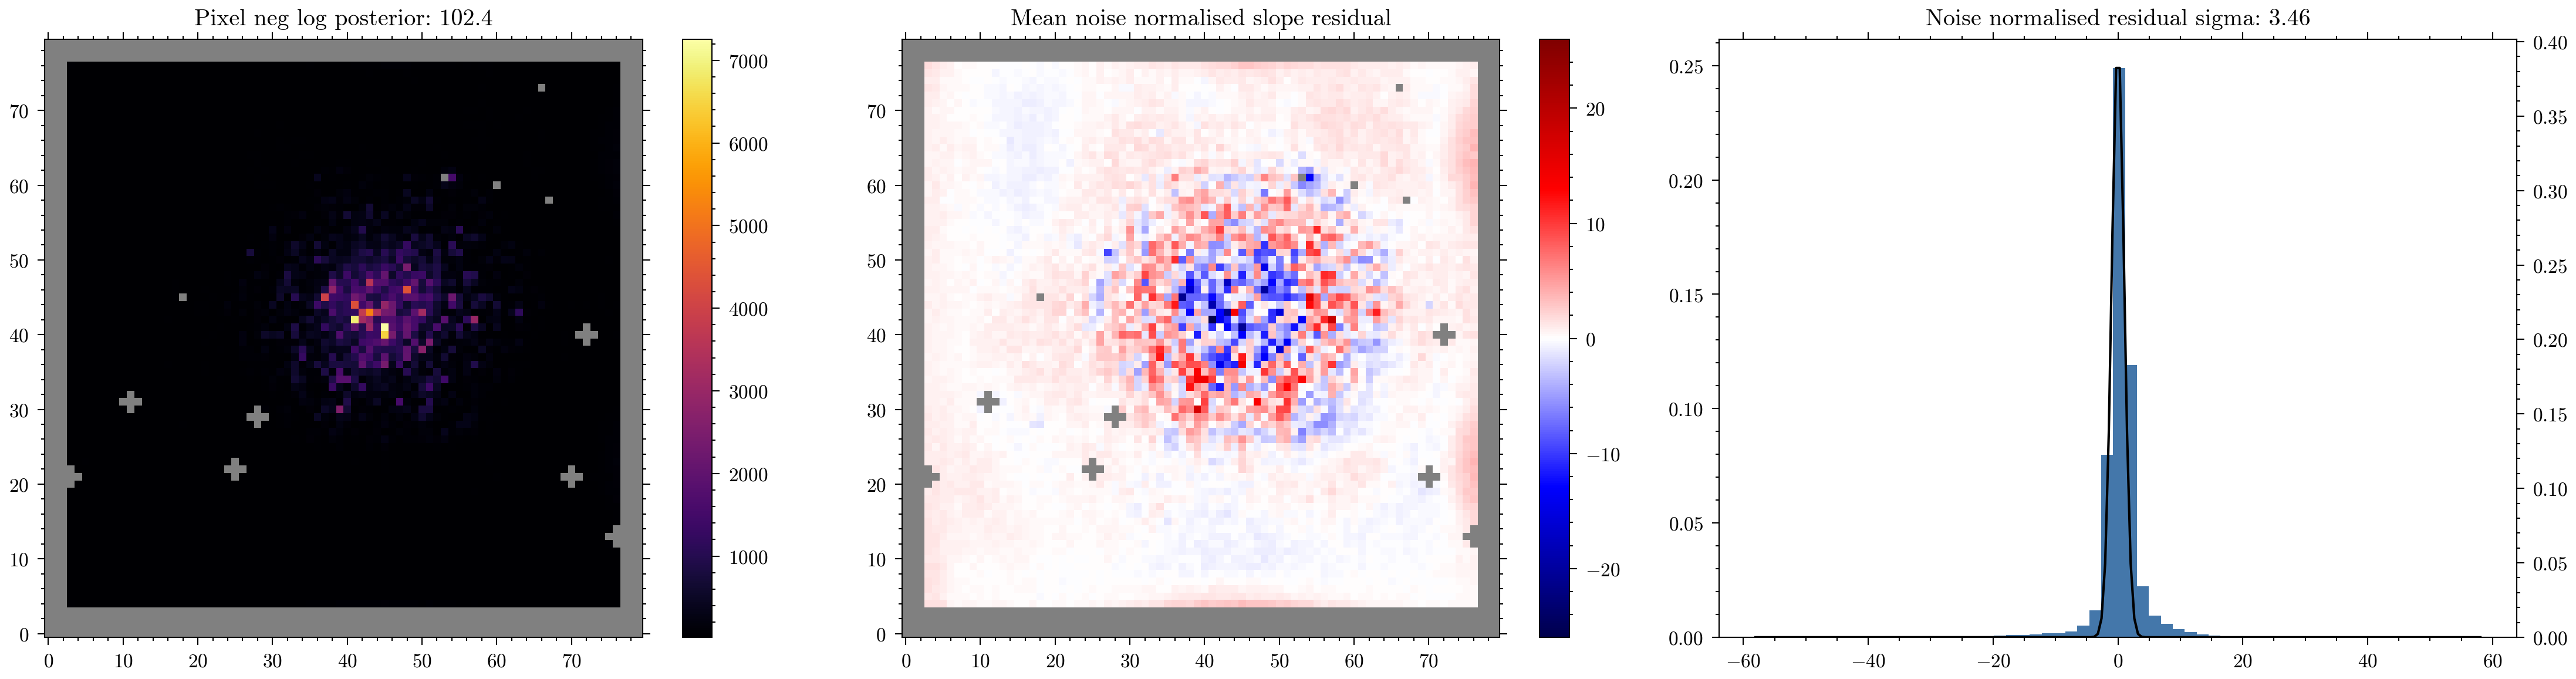

In [33]:
io_peak_flux = 10 ** np.array(list(io_final_model.log_distribution.values())).max()

for exp in io_exposures:

    try:
        dist = 10 ** io_final_model.log_distribution[exp.get_key("log_distribution")]
    except:
        continue

    time = astropy.time.Time(io_sci_files[0][0].header["EXPMID"], format="mjd").isot
    roll_angle = dorito.plotting.calc_parang(f)

    fig, ax = plt.subplots(1, 2, figsize=(6, 2.5))
    c0 = dorito.plotting.plot_result(
        ax[0],
        dist,
        roll_angle_degrees=-io_rolls[exp.filename],
        cmap="afmhot_10u",
        vmax=io_peak_flux,
        )
    c1 = dorito.plotting.plot_io_with_ephemeris(
        ax[1],
        dist,
        roll_angle_degrees=-io_rolls[exp.filename],
        # n_volc=0,
        cmap="bone_u",
        date=time,
        vmax=io_peak_flux,
    )

    fig.colorbar(c0)
    ax[0].set_title(f"Io: {time}")
    ax[1].set_title(f"Ephemeris")
    plt.tight_layout()
    # plt.savefig(save_dir + f"{time}.png", dpi=300)
    # plt.close()
    plt.show()

amigo.plotting.plot_losses(io_losses, start=int(n_epoch*0.75))
amigo.plotting.plot(io_histories)

for exp in io_exposures:
    exp.print_summary()
    amigo.plotting.summarise_fit(
        exp,
        io_final_model,
        # test_model,
    )

In [16]:
resids = (io_exposures[-1].slopes - io_final_model.model(io_exposures[-1]))

In [ ]:
for resid in resids:
    plt.figure(figsize=(2, 1))
    plt.imshow(np.where(io_exposures[-1].badpix, np.nan, resid), cmap="seismic", vmin=-40, vmax=40)
    plt.colorbar()
    plt.axis("off")
    plt.show()


In [23]:
for exp in io_exposures:
    if exp.calibrator:
        continue

    history = np.array(io_histories[exp.get_key("log_distribution")]["log_distribution"])

    np.save(reconstructions_dir + f"io/{exp.get_key('log_distribution')}_70.npy", history)

    for i, log_dist in enumerate(history):

        dist = 10 ** log_dist

        fig, ax = plt.subplots(1, 2, figsize=(6, 2), sharey=True)
        ax[0].set(title=f"{exp.filter}, iter {i}")

        im = dorito.plotting.plot_result(
            ax[0],
            dist,
            cmap="afmhot_10u",
            power=0.5,
            roll_angle_degrees=-io_rolls[exp.filename],
            # model=hdb_final_model,
            )
        fig.colorbar(im, ax=ax[0])

        ax[1].set(title=r"Convolved - $\lambda / 2D$")
        im = dorito.plotting.plot_result(
            ax[1],
            dorito.misc.blur_distribution(dist, io_final_model, exp, factor=0.5),
            cmap="afmhot_10u",
            power=0.5,
            roll_angle_degrees=-io_rolls[exp.filename],
            # model=hdb_final_model,
            )
        fig.colorbar(im, ax=ax[1])

        # plt.tight_layout()
        plt.savefig(gif_dir + f"io/{exp.filter}_{i:04d}.png", dpi=400)
        plt.close()
        # plt.show()

In [24]:
dorito.plotting.create_gif_from_dir(gif_dir + "io/", "70iter_on2D.gif", duration=5, loop=1)

# PDS 70

In [ ]:
pds_path = "/Users/mcha5804/JWST/PDS70/calslope/"

pds_files = file_fn(pds_path)
print(len(pds_files))

# nsci = 1; ncal = 4
pds_rolls = {}

pds_sci_files = []; pds_cal_files = []

for file in pds_files:

    filename = file[0].header["FILENAME"].replace("_nis_calslope.fits", "")
    pds_rolls[filename] = dorito.plotting.calc_parang(file)

    # manual bad pixel correction
    file["BADPIX"].data[58, 67] = 1
    file["BADPIX"].data[:, :3] = 1
    file["BADPIX"].data[:, -3:] = 1
    file["BADPIX"].data[:3, :] = 1
    file["BADPIX"].data[-3:, :] = 1
    file["BADPIX"].data[36:66, :25] = 1  # BACKGROUND STAR?
    # file["BADPIX"].data[40, 45] = 1  # MIDDLE PIXELS
    

    if file[0].header["TARGPROP"] == "TD-PDS-70":
        file[0].header["TARGPROP"] = "PDS 70"
        pds_sci_files.append(file)
    elif file[0].header["TARGPROP"] == "TD-CAL-HD-123991":
        file[0].header["TARGPROP"] = "HD 123991"
        pds_cal_files.append(file)
    else:
        print(f"Unkown target: {file[0].header['TARGPROP']}")

for f in pds_sci_files:
    print(f[0].header["TARGPROP"], f[0].header["NGROUPS"], f["SLOPE"].data.shape, f[0].header["FILTER"])

for f in pds_cal_files:
    print(f[0].header["TARGPROP"], f[0].header["NGROUPS"], f["SLOPE"].data.shape, f[0].header["FILTER"])

# dorito.misc.truncate_files(pds_sci_files, 28, 96)
# dorito.misc.truncate_files(pds_cal_files, 10, 29)


multi scale clean

In [139]:
pds_model, pds_params, pds_exposures = dorito.build_model.build_resolved_model(
    [pds_cal_files[-1]],
    [pds_sci_files[-1]],
    # pds_cal_files,
    # pds_sci_files,
    final_state,
    source_size=101,
    width=width,
    depth=depth,
    # log_dist_prior=np.log10(dorito.build_model.multi_gaussian_prior()),
    # log_dist_prior=np.log10(dorito.build_model.gaussian_prior()),
    # log_dist_prior=dorito.build_model.TD_prior(101, 0.948)
)
saved_params = np.load(init_state_cache + "PDS70/pds_all_filters.npy", allow_pickle=True)[()]

for param in ["positions", "fluxes", "aberrations"]:
    pds_params[param] = saved_params[param]

pds_model = pds_model.set("params", pds_params)


# pds_cal_exposures = pds_exposures[0]
# pds_sci_exposures = pds_exposures[1]

# pds_exposures = [*pds_cal_exposures, *pds_sci_exposures]

pds_model = pds_model.set("FF", np.ones_like(pds_model.FF))

# for exp in pds_cal_exposures:
#     exp.print_summary()

# for exp in pds_sci_exposures:
#     exp.print_summary()

In [ ]:
pds_fisher_params = [
    "positions",
    "fluxes",
    "aberrations",
    # "one_on_fs",
    # "log_distribution",
    "spectral_coeffs",
]

pds_fishers = amigo.fisher.calc_fishers(
    pds_model.set("ramp", None),
    pds_exposures,
    # pds_sci_exposures,
    pds_fisher_params,
    overwrite=True,
    # recalculate=True,
    )


In [23]:
def get_star_idx(arr):
    i = arr.shape[0] // 2
    return (i, i)

def star_regulariser(arr, prior=0.948, star_idx=None):
    """
    Regulariser to penalise a central pixel from straying from a given prior value."
    """
    # grabbing index of star
    if star_idx is None:
        star_idx = get_star_idx(arr)

    arr /= arr.sum()  # normalising
    star_flux = arr[star_idx]  # grabbing star pixel flux

    return (star_flux - prior) ** 2

In [ ]:
n_epoch = 100

config = {
    "positions": sgd(2e-1, 0),
    # "fluxes": sgd(5e-1, 2),
    # "aberrations": sgd(5e-2, 4),

    "fluxes": sgd(5e-2, 0),
    "aberrations": sgd(5e-3, 0),
    # "one_on_fs": sgd(1e2, 6),
    # "log_distribution": adam(2e-1, 7),#, (10, 0.25), b1=0.7),
    "log_distribution": adam(2e-2, 0),#, (10, 0.25), b1=0.7),
    # "source_spectrum.coefficients": sgd(1e-1, 5),
}

reg_dict = {
    # "L2": None,
    # "TV": None,
    # "QV": 1.0e-3,
    # "ME": None,
    "SF": 1e3,
}

args = {
    "reg_dict": reg_dict,
    # "reg_func_dict": dorito.stats.reg_func_dict,
    "reg_func_dict": {"SF": star_regulariser},
}

pds_final_model, pds_losses, _, pds_histories = amigo.fitting.optimise(
    pds_model,
    # pds_sci_exposures,
    pds_exposures,
    fishers=pds_fishers,
    optimisers=config,
    args=args,
    norm_fn=dorito.stats.normalise_distribution,
    loss_fn=dorito.stats.regularised_loss_fn,
    epochs=n_epoch,
    print_grads=False,
)

In [ ]:
for exp in pds_exposures:

    exp.print_summary()
    amigo.plotting.summarise_fit(
        exp,
        pds_final_model,
        residuals=True,
        histograms=True,
    )

    try:
        dist = pds_final_model.params["log_distribution"][exp.get_key("log_distribution")]
    except:
        continue

    seps = 1e-3 * np.array([150.5, 218.4])
    pas = np.array([131.2, 270.0])
    xs = seps*np.cos(np.radians(pas))
    ys = seps*np.sin(np.radians(pas))

    fig, ax = plt.subplots(figsize=(3, 2))
    ax.set(title=exp.filter)
    im = dorito.plotting.plot_result(
        ax,
        (10 ** dist).at[50, 50].set(np.nan),
        cmap="afmhot_10u",
        power=0.5,
        roll_angle_degrees=-pds_rolls[exp.filename],
        )
    ax.scatter(ys, xs, marker="o", alpha=0.9, s=80, facecolors="none", edgecolors="grey", linestyle="--", linewidths=0.7)
    ax.scatter([0], [0], marker="*", c="white", s=10)
    fig.colorbar(im, ax=ax)
    plt.show()


amigo.plotting.plot_losses(pds_losses, start=int(n_epoch*0.75))
amigo.plotting.plot(pds_histories)

# $HD\,135344B$

In [4]:
hdb_path = "/Users/mcha5804/JWST/HD135344B/calslope/"

hdb_files = file_fn(hdb_path)
print(len(hdb_files))

# nsci = 1; ncal = 4
hdb_rolls = {}

hdb_sci_files = []; hdb_cal_files = []

for file in hdb_files:

    filename = file[0].header["FILENAME"].replace("_nis_calslope.fits", "")
    hdb_rolls[filename] = dorito.plotting.calc_parang(file)

    # manual bad pixel correction
    file["BADPIX"].data[58, 67] = 1
    file["BADPIX"].data[:, :3] = 1
    file["BADPIX"].data[:, -3:] = 1
    file["BADPIX"].data[:3, :] = 1
    file["BADPIX"].data[-3:, :] = 1
    # file["BADPIX"].data[36:66, :25] = 1  # BACKGROUND STAR?
    # file["BADPIX"].data[40, 45] = 1  # MIDDLE PIXELS
    

    if file[0].header["TARGPROP"] == "TD-HD-135344B":
        file[0].header["TARGPROP"] = "HD 135344B"
        hdb_sci_files.append(file)
    elif file[0].header["TARGPROP"] == "TD-CAL-HD-123991":
        file[0].header["TARGPROP"] = "HD 123991"
        hdb_cal_files.append(file)
    else:
        print(f"Unkown target: {file[0].header['TARGPROP']}")

for f in hdb_sci_files:
    print(f[0].header["TARGPROP"], f[0].header["NGROUPS"], f["SLOPE"].data.shape, f[0].header["FILTER"])

for f in hdb_cal_files:
    print(f[0].header["TARGPROP"], f[0].header["NGROUPS"], f["SLOPE"].data.shape, f[0].header["FILTER"])

# dorito.misc.truncate_files(pds_sci_files, 28, 96)
# dorito.misc.truncate_files(pds_cal_files, 10, 29)


6
HD 135344B 3 (2, 80, 80) F380M
HD 135344B 2 (1, 80, 80) F430M
HD 135344B 3 (2, 80, 80) F480M
HD 123991 20 (19, 80, 80) F430M
HD 123991 10 (9, 80, 80) F380M
HD 123991 29 (28, 80, 80) F480M


In [5]:
source_size = 101

hdb_model, hdb_params, hdb_exposures = dorito.build_model.build_resolved_model(
    # hdb_cal_files,
    # hdb_sci_files,
    [hdb_cal_files[-1]],
    [hdb_sci_files[-1]],
    final_state,
    priors={
        "log_distribution": dorito.build_model.TD_prior(101, 0.97),
        "spectral_coeffs": np.array([1., 0.]),
    },
    width=width,
    depth=depth,
    # log_dist_prior=np.log10(dorito.build_model.multi_gaussian_prior()),
    # log_dist_prior=np.log10(dorito.build_model.gaussian_prior()),
    # log_dist_prior=dorito.build_model.TD_prior(101, 0.97),
)
saved_params = np.load(init_state_cache + "HD135344B/hdb_all_filters.npy", allow_pickle=True)[()]

for param in ["positions", "fluxes", "aberrations"]:
    hdb_params[param] = saved_params[param]

hdb_model = hdb_model.set("params", hdb_params)

hdb_model = hdb_model.set("FF", np.ones_like(hdb_model.FF))

/Users/mcha5804/miniconda3/envs/amigo/lib/python3.11/site-packages/amigo/ramp_models.py:327: UserWarning: A JAX array is being set as static! This can result in unexpected behavior and is usually a mistake to do.
  eqx.nn.Conv2d(
/Users/mcha5804/miniconda3/envs/amigo/lib/python3.11/site-packages/amigo/ramp_models.py:327: UserWarning: A JAX array is being set as static! This can result in unexpected behavior and is usually a mistake to do.
  eqx.nn.Conv2d(
/Users/mcha5804/miniconda3/envs/amigo/lib/python3.11/site-packages/amigo/ramp_models.py:327: UserWarning: A JAX array is being set as static! This can result in unexpected behavior and is usually a mistake to do.
  eqx.nn.Conv2d(
/Users/mcha5804/miniconda3/envs/amigo/lib/python3.11/site-packages/amigo/ramp_models.py:327: UserWarning: A JAX array is being set as static! This can result in unexpected behavior and is usually a mistake to do.
  eqx.nn.Conv2d(
/Users/mcha5804/miniconda3/envs/amigo/lib/python3.11/site-packages/amigo/ramp_mo

In [6]:
hdb_fisher_params = [
    "positions",
    "fluxes",
    "aberrations",
    # "one_on_fs",
    # "log_distribution",
    "spectral_coeffs",
]

hdb_fishers = amigo.fisher.calc_fishers(
    hdb_model.set("ramp", None),
    hdb_exposures,
    hdb_fisher_params,
    overwrite=True,
    # recalculate=True,
    )


  0%|          | 0/2 [00:00<?, ?it/s]

Could not calculate fisher for spectral_coeffs - 01242_004_02_03_1


In [10]:
n_epoch = 30

config = {
    "positions": sgd(2e-1, 0),
    # "fluxes": sgd(5e-1, 2),
    # "aberrations": sgd(5e-2, 4),

    "fluxes": sgd(5e-1, 0),
    "aberrations": sgd(5e-2, 0),
    # "one_on_fs": sgd(1e2, 6),
    "log_distribution": adam(1e-1, 7),#, (10, 0.25), b1=0.7),
    # "log_distribution": adam(3e-2, 2),#, (10, 0.25), b1=0.7),
    # "spectral_coeffs": sgd(1e-1, 50),
}

reg_dict = {
    # "L2": None,
    # "TV": None,
    # "TSV": 1.0e3,
    # "ME": 1.5e1,
    "SF": 1e3,
}

reg_func_dict = {
    "SF": lambda model, exposure, _: dorito.stats.star_reg(model, exposure, {"prior": 0.97, "star_idx": None}),
    # "ME": dorito.stats.regfunc_with_star(dorito.stats.ME),
    # "TSV": dorito.stats.regfunc_with_star(dorito.stats.TSV),
}

args = {
    "reg_dict": reg_dict,
    "reg_func_dict": reg_func_dict,
}

hdb_final_model, hdb_losses, _, hdb_histories = amigo.fitting.optimise(
    hdb_model,
    hdb_exposures,
    fishers=hdb_fishers,
    optimisers=config,
    args=args,
    norm_fn=dorito.stats.normalise_distribution,
    loss_fn=dorito.stats.regularised_loss_fn,
    epochs=n_epoch,
)

  0%|          | 0/30 [00:00<?, ?it/s]

Grad Batch fn compiling...
Compiling update function
Grad Batch fn compiling...
Compiling update function
Compile Time: 0:00:12
Initial Loss: 65.58
Est time per epoch:  0:00:05
Est run time:  0:02:47
Full Time: 0:03:08
Final Loss: 38.92


File 01242_004_02_03_1
Star HD 123991
Filter F480M
nints 418
ngroups 29



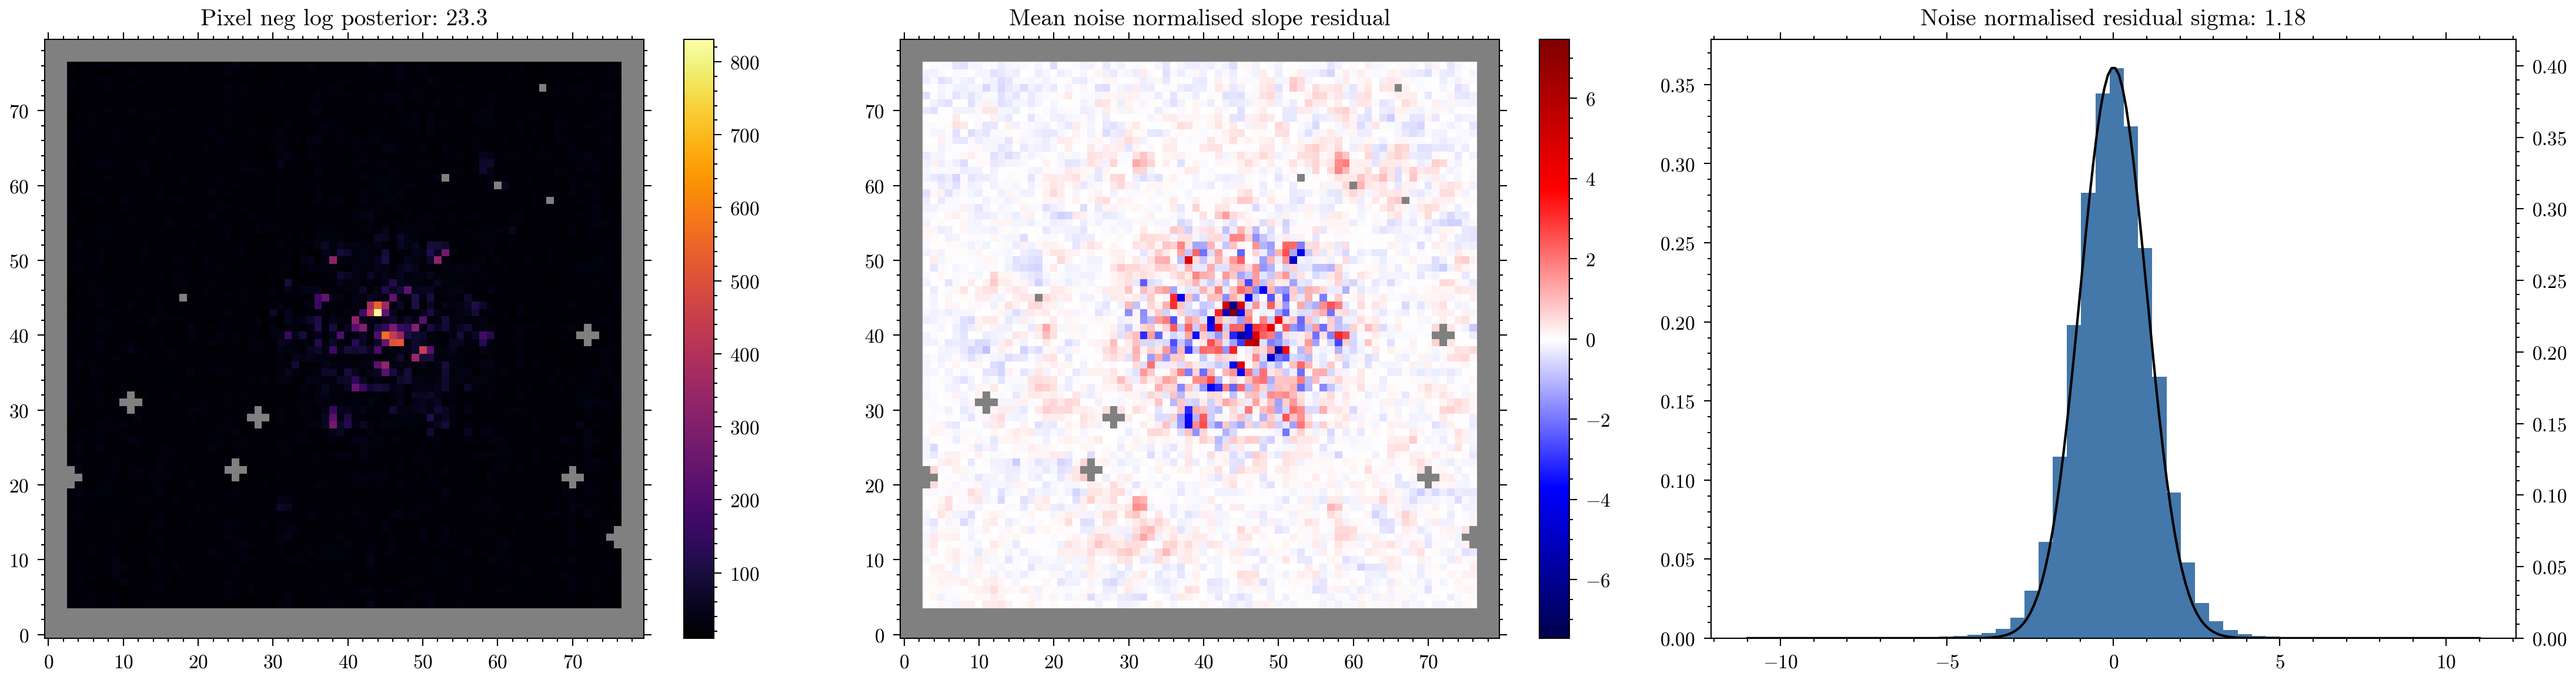

File 01242_003_02_03_1
Star HD 135344B
Filter F480M
nints 2541
ngroups 3



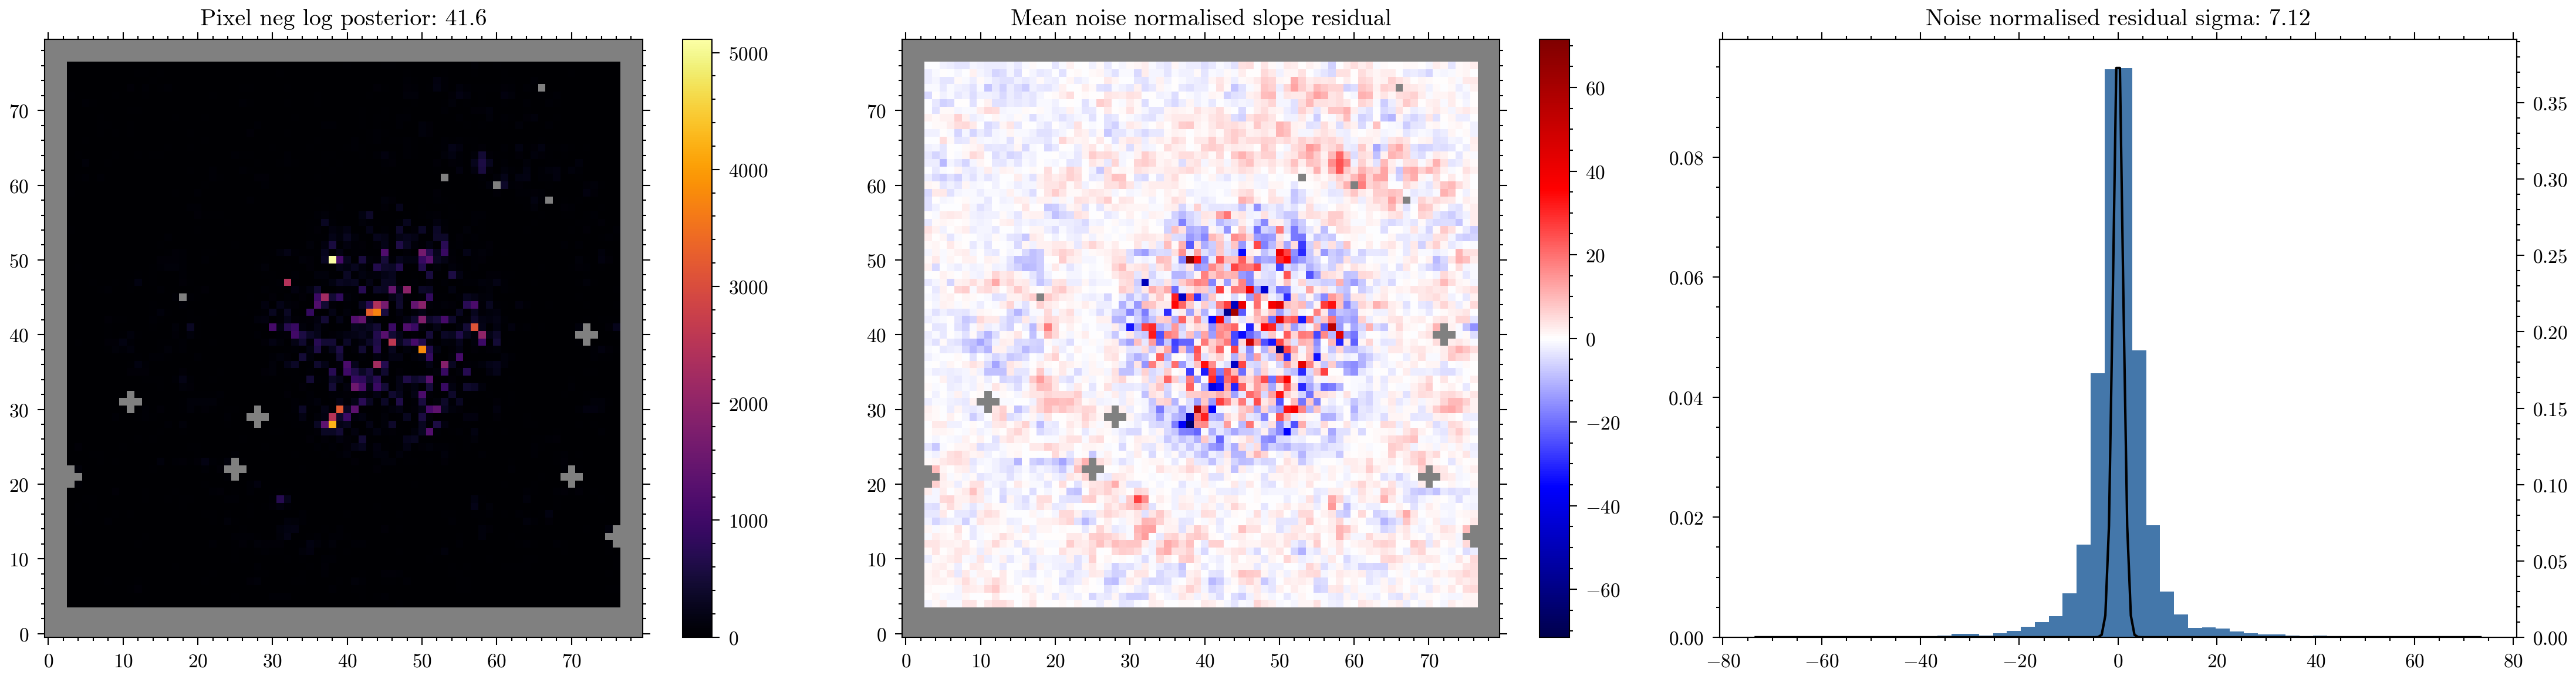

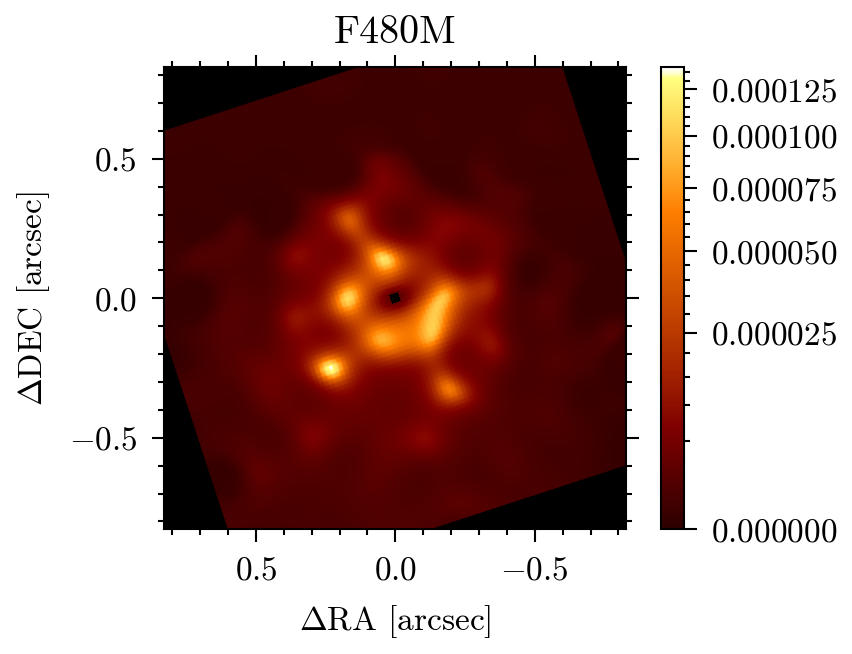

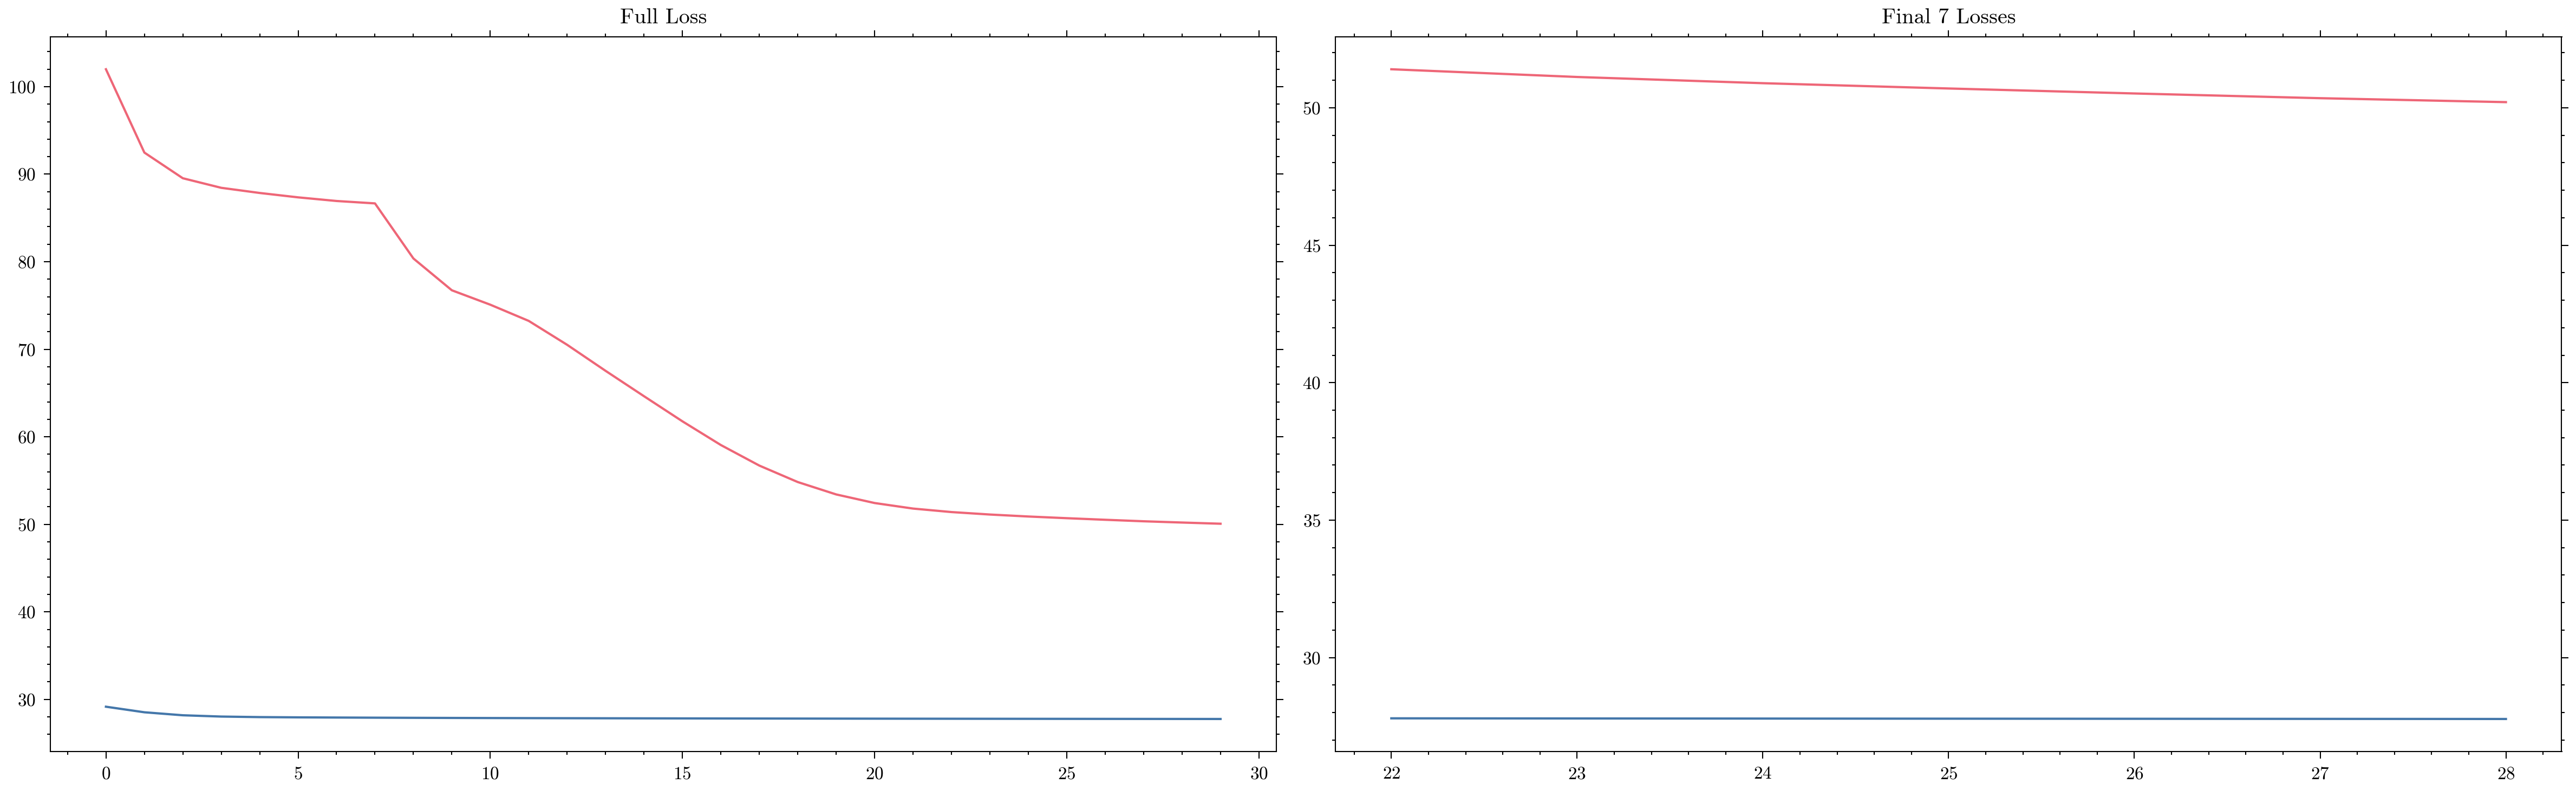

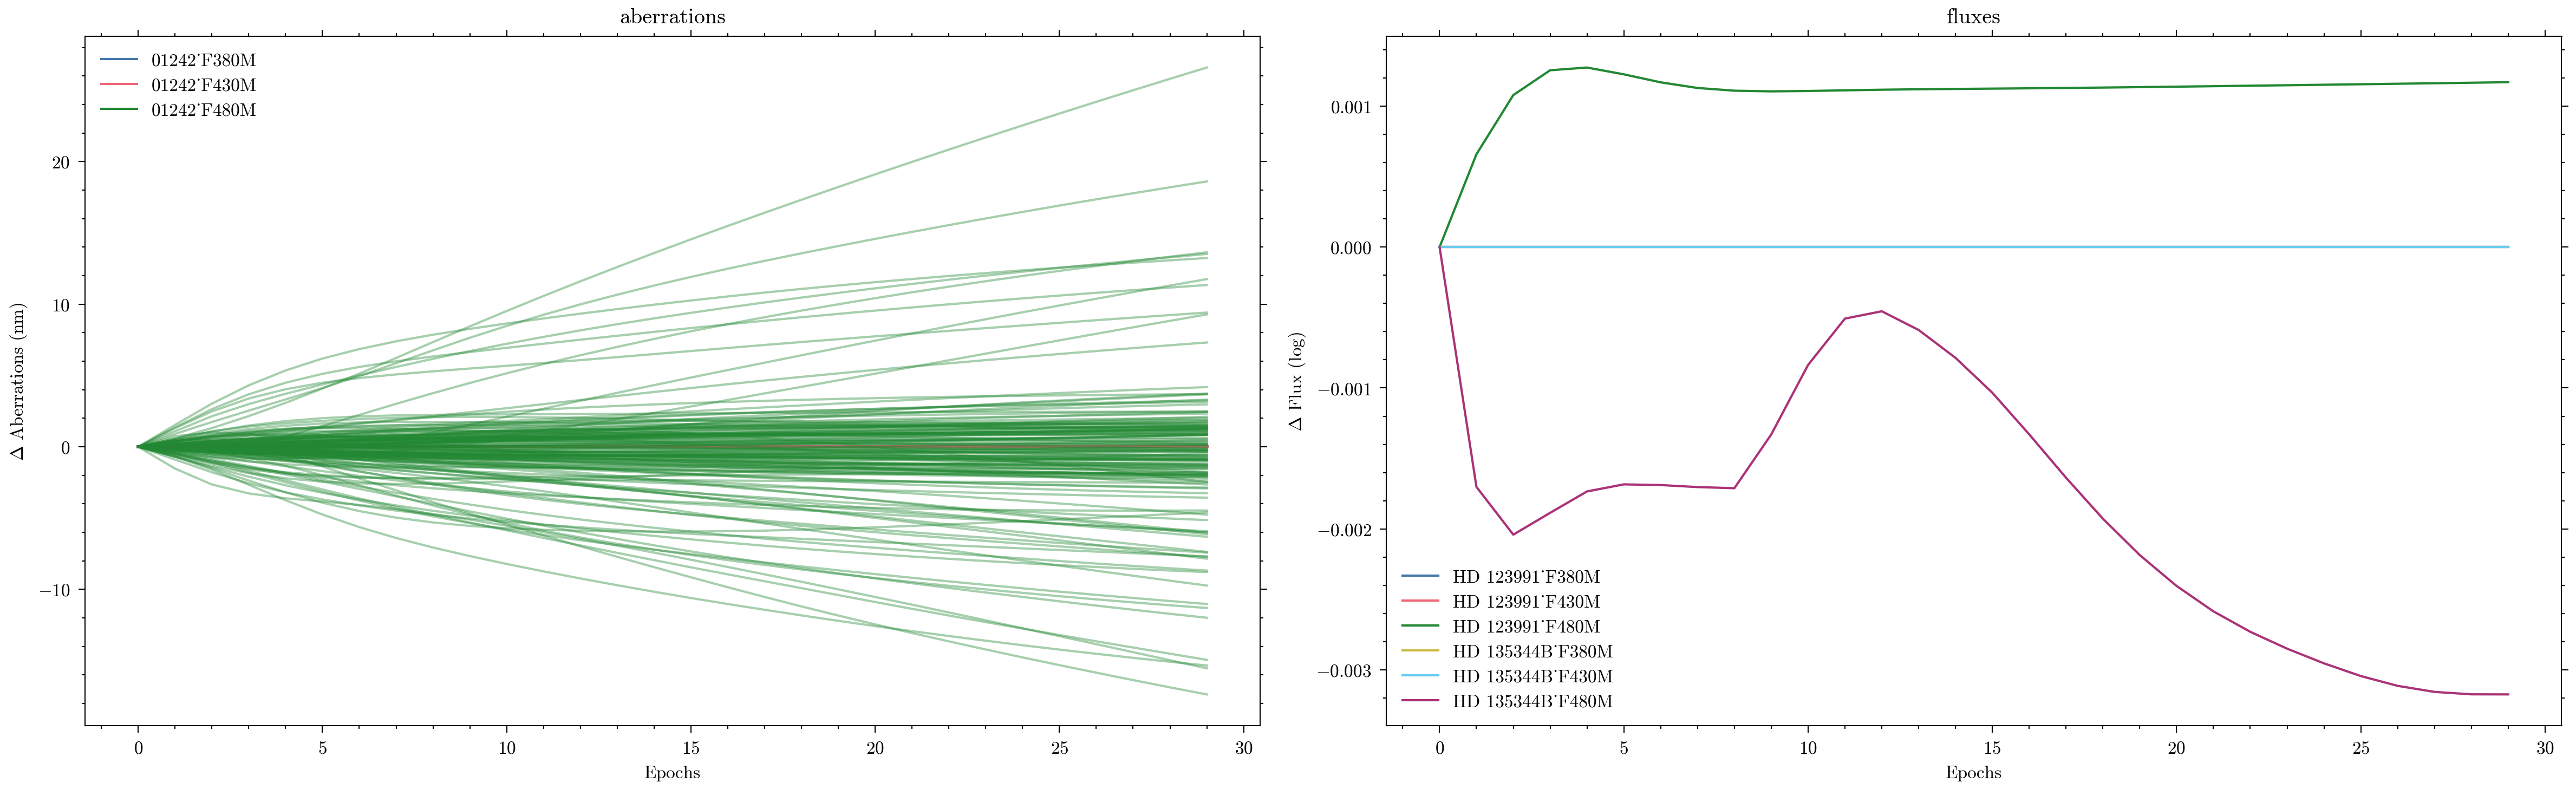

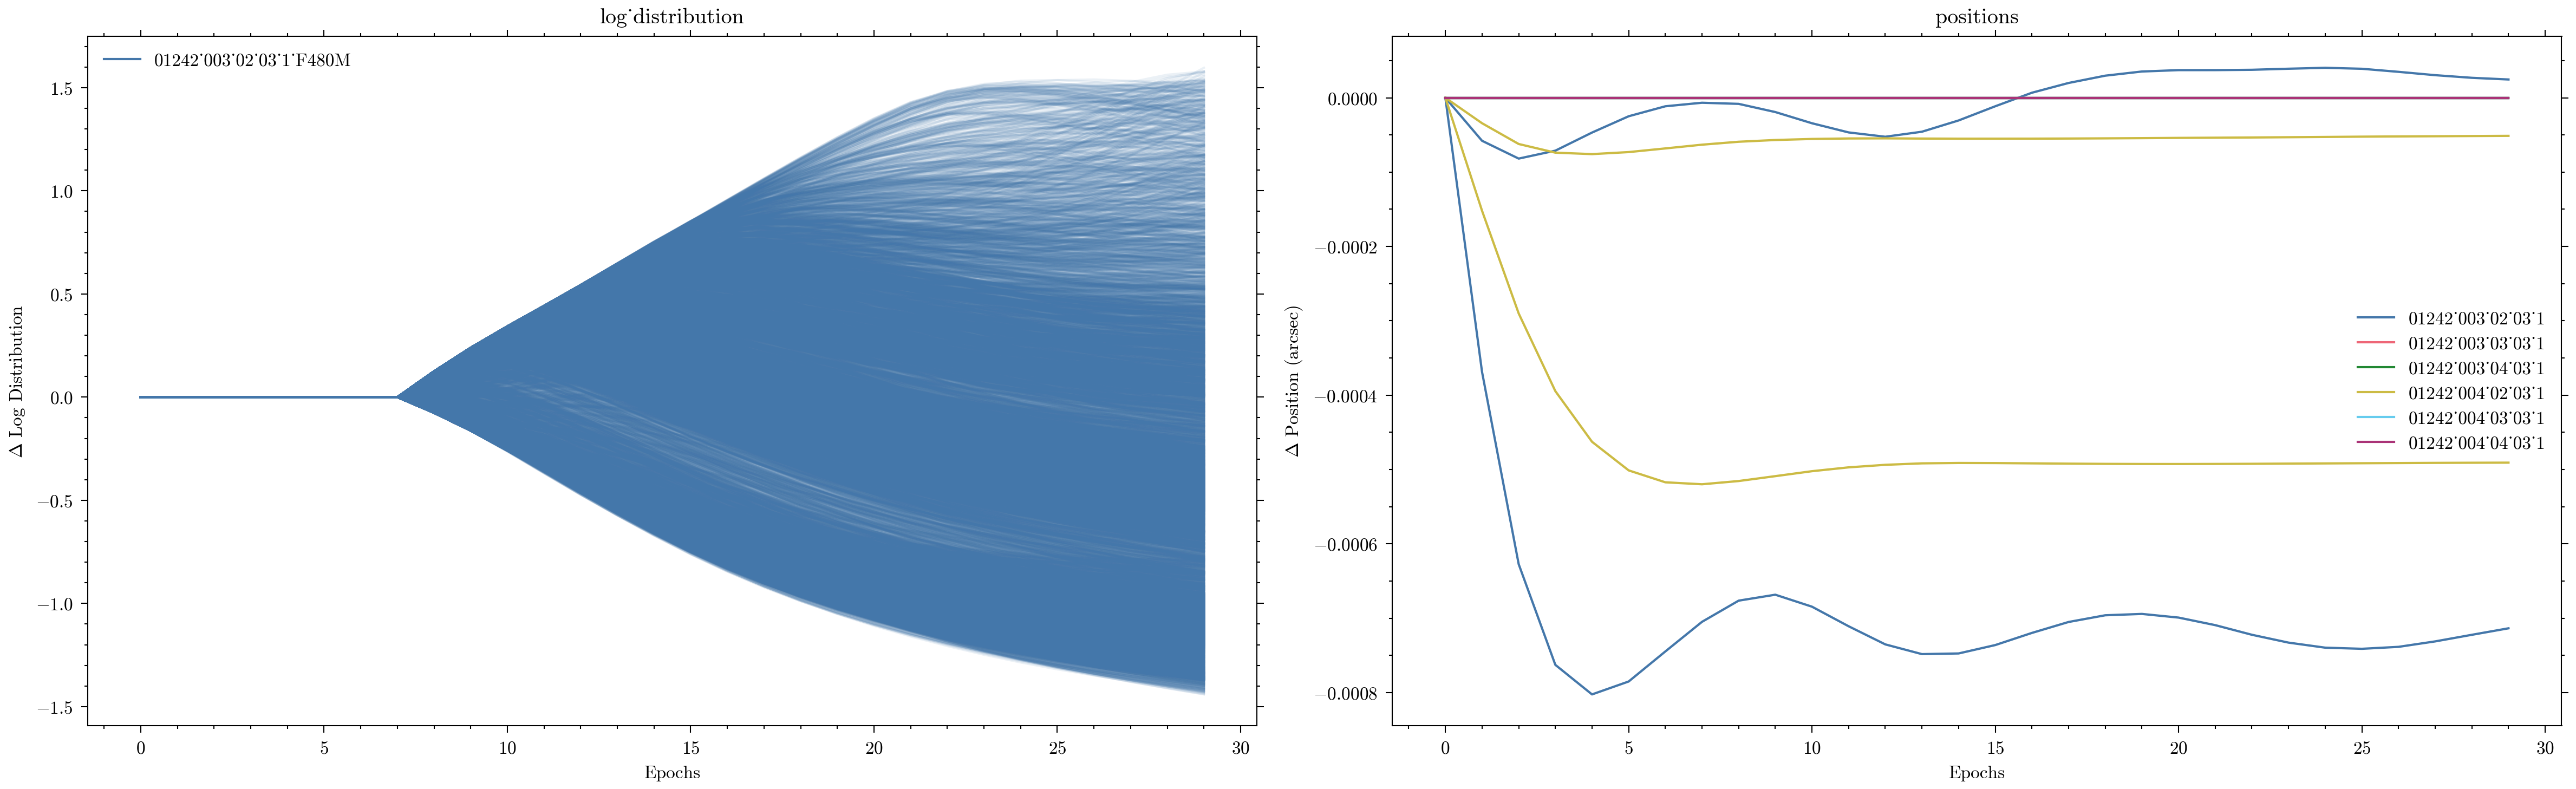

In [11]:
# np.save(init_state_cache + "HD135344B/hdb_all_filters.npy", hdb_final_model.params)

for exp in hdb_exposures:

    exp.print_summary()
    amigo.plotting.summarise_fit(
        exp,
        hdb_final_model,
    )

    try:
        dist = hdb_final_model.params["log_distribution"][exp.get_key("log_distribution")]
    except:
        continue

    fig, ax = plt.subplots(figsize=(3, 2))
    ax.set(title=exp.filter)
    im = dorito.plotting.plot_result(
        ax,
        (10 ** dist).at[50, 50].set(np.nan),
        cmap="afmhot_10u",
        power=0.5,
        roll_angle_degrees=-hdb_rolls[exp.filename],
        # model=hdb_final_model,
        )
    # ax.scatter(ys, xs, marker="o", alpha=0.9, s=80, facecolors="none", edgecolors="grey", linestyle="--", linewidths=0.7)
    # ax.scatter([0], [0], marker="*", c="white", s=10)
    # ax.grid(True, which='minor')
    fig.colorbar(im, ax=ax)
    plt.show()

amigo.plotting.plot_losses(hdb_losses, start=int(n_epoch*0.75))
amigo.plotting.plot(hdb_histories)

In [15]:
for exp in hdb_exposures:
    if exp.calibrator:
        continue

    history = np.array(hdb_histories[exp.get_key("log_distribution")]["log_distribution"])

    np.save(reconstructions_dir + f"sao/{exp.get_key('log_distribution')}1e3TSV_200.npy", history)

    # history = np.load(reconstructions_dir + f"sao/{exp.get_key('log_distribution')}_ME_300.npy")

    for i, log_dist in enumerate(history):

        dist = 10 ** log_dist

        fig, ax = plt.subplots(1, 2, figsize=(6, 2), sharey=True)
        ax[0].set(title=f"{exp.filter}, iter {i}")

        im = dorito.plotting.plot_result(
            ax[0],
            dist.at[50, 50].set(np.nan),
            cmap="afmhot_10u",
            power=0.5,
            roll_angle_degrees=-hdb_rolls[exp.filename],
            # model=hdb_final_model,
            )
        fig.colorbar(im, ax=ax[0])

        ax[1].set(title=r"Convolved - $\lambda / D$")
        im = dorito.plotting.plot_result(
            ax[1],
            dorito.misc.blur_distribution(dist.at[50, 50].set(0.), hdb_model, exp, factor=1),
            cmap="afmhot_10u",
            power=0.5,
            roll_angle_degrees=-hdb_rolls[exp.filename],
            # model=hdb_final_model,
            )
        fig.colorbar(im, ax=ax[1])

        # plt.tight_layout()
        plt.savefig(gif_dir + f"sao/{exp.filter}_{i:04d}.png", dpi=400)
        plt.close()
        # plt.show()

In [16]:
dorito.plotting.create_gif_from_dir(gif_dir + "sao/", "1e3TSV_200.gif", duration=10, loop=1)

In [11]:
def apply_regularisers(model, exposure, args):
        
        distribution = 10 ** model.params["log_distribution"][exposure.get_key("log_distribution")]

        # creating a list of regularisation functions and regularisation hyperparameters
        fn_list = [args["reg_func_dict"][reg] for reg in args["reg_dict"].keys()]
        coeff_list = list(args["reg_dict"].values())

        # evaluating the regularisation term with each for each regulariser
        priors = [coeff * fn(distribution) for coeff, fn in zip(coeff_list, fn_list)]
        prior = np.array(priors).sum()  # summing the different regularisers

        return prior


def regularised_loss_fn(model, exposure, args):
    # this is per exposure

    # regular likelihood term
    likelihood = amigo.stats.reg_loss_fn(model, exposure, args)

    # grabbing and exponentiating log distributions
    if not exposure.calibrator:
        prior = apply_regularisers(model, exposure, args)

    else:
        prior = np.array(0.0)

    return likelihood + prior


def prior_data_loss(model, exposure, args):

    # regular likelihood term
    likelihood = amigo.stats.reg_loss_fn(model, exposure, args)

    # grabbing and exponentiating log distributions
    if not exposure.calibrator:
        prior = apply_regularisers(model, exposure, args)

    else:
        prior = np.array(0.0)

    return likelihood, prior

In [13]:
prior_data_loss(hdb_final_model, hdb_exposures[1], args)

(Array(46.5367012, dtype=float64), Array(0.24684435, dtype=float64))

# WR 137

In [ ]:
wr137_path = "/Users/mcha5804/JWST/WR137/calslope/"

nsci = 1; ncal = 2

wr137_files = file_fn(wr137_path, filters=["F480M"])
wr137_sci_files = []; wr137_cal_files = []
wr_rolls = {}

for file in wr137_files:

    filename = file[0].header["FILENAME"].replace("_nis_calslope.fits", "")
    wr_rolls[filename] = dorito.plotting.calc_parang(file)

    # manual bad pixel correction
    file["BADPIX"].data[58, 67] = 1
    file["BADPIX"].data[:, :3] = 1
    file["BADPIX"].data[:, -3:] = 1
    file["BADPIX"].data[:3, :] = 1
    file["BADPIX"].data[-3:, :] = 1

    if file[0].header["TARGPROP"] == "WR137":
        wr137_sci_files.append(file)
    elif file[0].header["TARGPROP"] == "WR137AMIREFPSF":
        wr137_cal_files.append(file)
    else:
        print(f"Unkown target: {file[0].header['TARGPROP']}")

if nsci is not None:
    wr137_sci_files = wr137_sci_files[:nsci]

if ncal is not None:
    wr137_cal_files = wr137_cal_files[:ncal]

for f in wr137_sci_files:
    print(f[0].header["TARGPROP"], f[0].header["NGROUPS"], f[0].header["FILTER"], f[1].data.shape)

for f in wr137_cal_files:
    print(f[0].header["TARGPROP"], f[0].header["NGROUPS"], f[0].header["FILTER"], f[1].data.shape)

In [28]:
wr_model, wr_params, wr_exposures = build_resolved_model(
    wr137_cal_files,
    wr137_sci_files,
    final_state,
    separate_exposures=False,
    # log_dist_prior=np.log10(dorito.build_model.multi_gaussian_prior(contrast=0.01)),
)

wr_model = wr_model.set("FF", np.ones_like(wr_model.FF))


In [ ]:
fisher_params = [
    "positions",
    "aberrations",
    "fluxes",
    # "one_on_fs",
    # "log_distribution",
    # "spectral_coeffs",
]
wr_fishers = amigo.fisher.calc_fishers(wr_model.set("ramp", None), wr_exposures, fisher_params, overwrite=True, recalculate=False)

In [ ]:
n_epoch = 40

config = {
    "positions": sgd(2e-1, 0),
    "fluxes": sgd(5e-1, 2),
    "aberrations": sgd(5e-2, 4),

    # "fluxes": sgd(5e-1, 0),
    # "aberrations": sgd(5e-2, 0),
    # "one_on_fs": sgd(1e2, 6),
    "log_distribution": adam(1e-1, 7),#, (10, 0.25), b1=0.7),
    # "log_distribution": adam(3e-2, 2),#, (10, 0.25), b1=0.7),
    # "spectral_coeffs": sgd(1e-1, 50),
}

reg_dict = {
    # "L2": None,
    # "TV": None,
    # "TSV": 1.0e2,
    # "ME": 0.5e1,
    # "SF": 1e3,
}

reg_func_dict = {
    "ME": dorito.stats.regfunc_with_star(dorito.stats.ME_loss),
    # "TSV": dorito.stats.TSV_with_star,
}

args = {
    "reg_dict": reg_dict,
    "reg_func_dict": reg_func_dict,
}

wr_final_model, wr_losses, _, wr_histories = amigo.fitting.optimise(
    wr_model,
    wr_exposures,
    fishers=wr_fishers,
    optimisers=config,
    args=args,
    norm_fn=dorito.stats.normalise_distribution,
    loss_fn=dorito.stats.regularised_loss_fn,
    epochs=n_epoch,
)

In [ ]:
# np.save(init_state_cache + "HD135344B/hdb_all_filters.npy", hdb_final_model.params)

for exp in wr_exposures:

    exp.print_summary()
    amigo.plotting.summarise_fit(
        exp,
        wr_final_model,
    )

    try:
        dist = wr_final_model.params["log_distribution"][exp.get_key("log_distribution")]
    except:
        continue

    fig, ax = plt.subplots(figsize=(3, 2))
    ax.set(title=exp.filter)
    im = dorito.plotting.plot_result(
        ax,
        (10 ** dist),
        cmap="afmhot_10u",
        power=0.5,
        roll_angle_degrees=-wr_rolls[exp.filename],
        # model=wr_final_model,
        )
    fig.colorbar(im, ax=ax)
    plt.show()

amigo.plotting.plot_losses(wr_losses, start=int(n_epoch*0.75))
amigo.plotting.plot(wr_histories)

In [ ]:
Z = 10 ** dist


plt.contour(
    Z,
    levels = np.logspace(np.log10(Z.min()), np.log10(Z.max()), 3),
    colors="red",
    # norm=mpl.colors.LogNorm(),
    )
plt.colorbar()
plt.show()

In [23]:
def calc_parang(file):
    """
    Calculate the parallactic angle for a given file.
    """
    return np.array(file["PRIMARY"].header["ROLL_REF"] - file["PRIMARY"].header["V3I_YANG"])

# Wavelets Io

In [4]:
from amigo.model_fits import ModelFit
from dorito.model_fits import ResolvedFit
from dorito.models import ResolvedAmigoModel
from jax import Array, numpy as np, vmap
import jaxwt
import jax.tree as jtu
import jaxshearlab.pyShearLab2D as jsl
from abc import abstractmethod


def normalise_wavelets(model, model_params, args, key):
    params = model_params.params

    if "wavelets" not in params.keys():
        return model_params, key
    
    # this is only to use methods! Does not update outside this function
    model = model.set("params", params)
        
    for k in params["wavelets"].keys():

        # reconstructing, normalising
        distribution = model._get_distribution_from_key(k)
        distribution = np.clip(distribution, 0.)
        distribution = distribution / distribution.sum()

        # converting to wavelet coefficients
        norm_wavelets = model.wavelet_transform(distribution)
        norm_coeffs = model.flatten_wavelets(norm_wavelets)
    
        # re-assigning
        params["wavelets"][k] = norm_coeffs

    return model_params.set("params", params), key


def wavelet_prior(source_size, level=None, wavelet="db2"):
    """
    Creates a set of wavelet coefficients for a given source
    size and level, corresponding to a normalised uniform array.

    Parameters
    ----------
    source_size : int
        The size of the image after an inverse wavelet transformation.
    level : int | None
        The number of wavelet levels to use. If None, the maximum
        possible level is used.
    wavelet : str
        The wavelet basis to use, default is 'db2'.

    Returns
    -------
    coeffs : tuple
        A tuple of wavelet coefficients, with the first element
        corresponding to the approximation coefficients.
    """

    ones = np.ones((source_size, source_size))
    ones = ones / ones.sum()

    return jaxwt.wavedec2(ones, wavelet, level=level)


def shearlet_prior(source_size=None, nScales=2, shearletSystem=None):
    """
    Creates a set of shearlet coefficients for a given source
    corresponding to a normalised uniform array.

    Parameters
    ----------
    source_size : int
        The size of the image after an inverse wavelet transformation.
    nScales : int
        The number of scales to use.
    shearletSystem : None
        A pre-defined shearlet system. If None, a new system
        is created.

    Returns
    -------
    shearlets : Array
        The shearlet coefficients.
    shearletSystem : jsl.pyShearLab2D.SLgetShearletSystem2D
        The shearlet system used to calculate the coefficients
    """

    if shearletSystem is None:
        if source_size is None:
            raise ValueError("Source size must be provided if no shearlet system is provided.")

        shearletSystem = jsl.SLgetShearletSystem2D(
            useGPU=0,
            rows=source_size,
            cols=source_size,
            nScales=nScales,
        )

    # creating a uniform distribution
    ones = np.ones((source_size, source_size))
    ones = ones / ones.sum()

    # transofrming to shearlet coefficients
    shearlets = jsl.SLsheardec2D(ones, shearletSystem)

    return shearlets, shearletSystem


class BaseWaveletModel(ResolvedAmigoModel):

    shapes: list
    sizes: list
    starts: list
    tree_def: None

    def __init__(
            self,
            params,
            optics,
            ramp,
            detector,
            read,
            filters,
            exposures=None,
            wavelets=None,
            ):

        if exposures is None:
            raise ValueError("Exposures must be provided.")

        waveleaves, tree_def = jtu.flatten(wavelets)
        coeffs = np.concatenate([val.flatten() for val in waveleaves])

        self.shapes = [v.shape for v in waveleaves]
        self.sizes = [int(v.size) for v in waveleaves]
        self.starts = [int(i) for i in np.cumsum(np.array([0] + self.sizes))]
        self.tree_def = tree_def

        wavelet_dict = {}
        for exp in exposures:
            if not exp.calibrator:
                key = exp.get_key("wavelets")
                wavelet_dict[key] = coeffs

        params["wavelets"] = wavelet_dict

        super().__init__(
            params=params,
            optics=optics,
            ramp=ramp,
            detector=detector,
            read=read,
            filters=filters,
        )


    def flatten_wavelets(self, wavelets):
        waveleaves, _ = jtu.flatten(wavelets)
        return np.concatenate([val.flatten() for val in waveleaves])


    def _wavelet_coeffs_from_key(self, exp_key):

        wavalues = self.params["wavelets"][exp_key]

        waveleaves = [
            jax.lax.dynamic_slice(wavalues, (start,), (size,)).reshape(shape)
            for start, size, shape in zip(self.starts, self.sizes, self.shapes)
        ]
        return jtu.unflatten(self.tree_def, waveleaves)

    def wavelet_coeffs(self, exposure):
        return self._wavelet_coeffs_from_key(exposure.get_key("wavelets"))

    @abstractmethod
    def _get_distribution_from_key(self, exp_key) -> Array:
        """
        Returns the normalised intensity distribution of the source.
        """

    def get_distribution(self, exposure) -> Array:
        """
        Returns the normalised intensity distribution of the source.
        """
        return self._get_distribution_from_key(exposure.get_key("wavelets"))
    
    @abstractmethod
    def wavelet_transform(self, exposure) -> Array:
        """
        Returns the wavelet coefficients of for a given distribution.
        """
   

class WaveletModel(BaseWaveletModel):

    wavelet: str = "db2"
    level: int = None
    
    def __init__(
            self,
            params,
            optics,
            ramp,
            detector,
            read,
            filters,
            exposures=None,
            wavelets=None,
            source_size=98,
            level=None,
            wavelet="db2",
            ):

        if wavelets is None:
            if source_size is None or level is None:
                raise ValueError("Source size and level must be provided if wavelets are not.")
            wavelets = dorito.build_model.wavelet_prior(source_size, level=level)

        self.wavelet = wavelet
        self.level = level

        super().__init__(
            params=params,
            optics=optics,
            ramp=ramp,
            detector=detector,
            read=read,
            filters=filters,
            exposures=exposures,
            wavelets=wavelets,
        )

    def _get_distribution_from_key(self, exp_key) -> Array:
        """
        Returns the normalised intensity distribution of the source.
        """
        wavelet_coeffs = self._wavelet_coeffs_from_key(exp_key)
        distribution = jaxwt.waverec2(wavelet_coeffs, self.wavelet)[0]
        return distribution
    
    def wavelet_transform(self, array) -> Array:
        # converting to wavelet coefficients
        return jaxwt.conv_fwt_2d.wavedec2(
            array,
            self.wavelet,
            level=self.level,
        )


class ShearletModel(BaseWaveletModel):

    shearletSystem: None

    def __init__(
        self,
        params,
        optics,
        ramp,
        detector,
        read,
        filters,
        exposures=None,
        source_size=98,
        wavelets=None,
        shearletSystem=None,
        ):

        if wavelets is None:
            if shearletSystem is not None:
                wavelets, _ = shearlet_prior(
                    source_size,
                    shearletSystem=shearletSystem,
                    depth=depth,
                    )

            elif shearletSystem is None:
                wavelets, shearletSystem = shearlet_prior(
                    source_size,
                    depth=depth
                    )

        self.shearletSystem = shearletSystem

        super().__init__(
            params=params,
            optics=optics,
            ramp=ramp,
            detector=detector,
            read=read,
            filters=filters,
            exposures=exposures,
            wavelets=wavelets,
        )
        

    def _get_distribution_from_key(self, exp_key) -> Array:
        """
        Returns the normalised intensity distribution of the source.
        """
        wavelet_coeffs = self._wavelet_coeffs_from_key(exp_key)
        return jsl.SLshearrec2D(wavelet_coeffs, self.shearletSystem)
    
    def wavelet_transform(self, array) -> Array:
        return jsl.SLsheardec2D(array, self.shearletSystem)


class WaveletFit(ResolvedFit):

    def get_key(self, exposure, param):
        match param:
            case "wavelets":
                return exposure.filter

        return super().get_key(exposure, param)

    def map_param(self, exposure, param):
        match param:
            case "wavelets":
                return f"{param}.{exposure.get_key(param)}"

        return super().map_param(exposure, param)
    
    def __call__(self, model, exposure):
        psf = self.model_psf(model, exposure)
        image = psf.convolve(model.get_distribution(exposure), method="fft")
        image = self.model_detector(image, model, exposure)
        ramp = self.model_ramp(image, model, exposure)
        return self.model_read(ramp, model, exposure)
    

In [5]:
io_path = "/Users/mcha5804/JWST/IO/calslope/"

io_files = file_fn(io_path)

nsci = 1; ncal = 1

io_sci_files = []; io_cal_files = []
io_rolls = {}

for file in io_files:

    # manual bad pixel correction
    file["BADPIX"].data[58, 67] = 1
    file["BADPIX"].data[-3:, :] = 1
    file["BADPIX"].data[:, :3] = 1
    file["BADPIX"].data[:, -3:] = 1
    file["BADPIX"].data[:3, :] = 1
    file["BADPIX"].data[-3:, :] = 1

    filename = file[0].header["FILENAME"].replace("_nis_calslope.fits", "")
    io_rolls[filename] = dorito.plotting.calc_parang(file)

    if file[0].header["TARGPROP"] == "IO":
        io_sci_files.append(file)
    elif file[0].header["TARGPROP"] == "PSFCAL.2022A-HD2236-K6":
        file[0].header["TARGPROP"] = "HD 2236"
        io_cal_files.append(file)
    else:
        print(f"Unkown target: {file[0].header['TARGPROP']}")

io_cal_files = io_cal_files[4-ncal:]
io_sci_files = io_sci_files[:nsci]
dorito.misc.truncate_files(io_sci_files, 18, 45)

for f in io_sci_files:
    print(f[0].header["TARGPROP"], f[0].header["NGROUPS"], f["SLOPE"].data.shape)

for f in io_cal_files:
    print(f[0].header["TARGPROP"], f[0].header["NGROUPS"], f["SLOPE"].data.shape)

IO 45 (17, 80, 80)
HD 2236 12 (11, 80, 80)


In [6]:
data_path = "/Users/mcha5804/Library/CloudStorage/OneDrive-TheUniversityofSydney(Students)/PyCharm/jwst/io/reconstructions/"
img = 10 ** np.load(data_path + "io/01373_017_02_04_3_F430M_70.npy")[-1]

img = img / img.sum()

prIOr = jaxwt.conv_fwt_2d.wavedec2(img, "db2")


NameError: name 'jaxwt' is not defined

In [7]:
source_size = 98
level = 1
wavelet = "db2"

shearlets, shearletSystem = dorito.build_model.shearlet_prior(source_size, nScales=2)

io_model, io_params, io_exposures = dorito.build_model.build_resolved_model(
    io_cal_files,
    io_sci_files,
    final_state,
    width=width,
    depth=depth,
    # ramp_model=ode_model,
    # modeller=WaveletModel,
    modeller=amigo.models.ShearletModel,
    sci_fit=WaveletFit(),
    extra_params=[
        "wavelets",
        # "log_distribution",
        "spectral_coeffs",
        ],
    priors={
        # "wavelets": wavelet_prior(source_size, level=level, wavelet=wavelet),
        "wavelets": shearlets,
        # "log_distribution": np.log10(np.ones((source_size, source_size)) / source_size**2),
        "spectral_coeffs": np.array([1., 0.]),
        },
    # level=level,
    # wavelet=wavelet,
    shearletSystem=shearletSystem,
    # separate_exposures=True,
)

# io_exposures = [*io_cal_exposures, *io_sci_exposures]
io_model = io_model.set("FF", np.ones_like(io_model.FF))

io_init_state = np.load(init_state_cache + "io/io_setup2.npy", allow_pickle=True)[()]

for p in [
    "positions",
    "fluxes",
    "aberrations"
    ]:
    io_params[p] = io_init_state[p]

io_model = io_model.set("params", io_params)
# io_model = io_model.set("ramp", ode_model)  # TODO want this?
# io_model = amigo.misc.populate_from_state(io_model, final_state)



AttributeError: module 'amigo' has no attribute 'models'

In [8]:
# io_fisher_params = list(io_params.keys())

io_fisher_params = [
    "positions",
    "fluxes",
    "aberrations",
    # "wavelets",
    # "one_on_fs",
    # "log_distribution",
    # "spectral_coeffs",
]

# rampless_model = cal_model.set("ramp", None)
io_fishers = amigo.fisher.calc_fishers(
    io_model.set("ramp", None),
    # io_cal_exposures,
    io_exposures,
    io_fisher_params,
    overwrite=True,
    recalculate=False,
    )

  0%|          | 0/2 [00:00<?, ?it/s]

In [9]:
n_epoch = 100

config = {
    # "positions": sgd(5e-1, 0), # (learning_rate, start epoch)
    # "fluxes": sgd(1e-1, 2),
    # "aberrations": sgd(4e-2, 4),

    # "positions": sgd(2e-1, 0),
    "fluxes": sgd(0.5e-1, 0),
    # "aberrations": sgd(2e-2, 0),

    "wavelets": adam(1e-5, 0),
    # "one_on_fs": sgd(1e2, 6),
    # "log_distribution": adam(2e-1, 8),#, (10, 0.25), b1=0.7),
    # "log_distribution": adam(2e-1, 3),#, (10, 0.25), b1=0.7),
    # "source_spectrum.coefficients": sgd(1e-1, 5),
}

reg_dict = {
    "L1": 5.0e-5,
    # "L2": None,
    # "TV": None,
    # "QV": 1.0e-3,
    # "ME": None,
    # "SF": 1e3,
}

args = {
    "reg_dict": reg_dict,
    # # "reg_func_dict": dorito.stats.reg_func_dict,
    "reg_func_dict": {"L1": dorito.stats.L1_on_wavelets},
}

io_final_model, io_losses, _, io_histories = amigo.fitting.optimise(
    io_model,
    io_exposures,
    fishers=io_fishers,
    loss_fn=dorito.stats.regularised_loss_fn,
    args=args,
    norm_fn=normalise_wavelets,
    optimisers=config,
    epochs=n_epoch,
    print_grads=False,
)

balance = dorito.stats.prior_data_loss(io_final_model, io_exposures[-1], args)
print(f"Likelihood: {balance[0]:.3e}, Prior: {balance[1]:.3e}")


/Users/mcha5804/miniconda3/envs/amigo/lib/python3.11/site-packages/jax/_src/numpy/lax_numpy.py:3459: ComplexWarning: Casting complex values to real discards the imaginary part
  out_array: Array = lax_internal._convert_element_type(


  0%|          | 0/100 [00:00<?, ?it/s]

Grad Batch fn compiling...
Compiling update function
Grad Batch fn compiling...
Compiling update function
Compile Time: 0:00:10
Initial Loss: 6,960.15
Est time per epoch:  0:00:03
Est run time:  0:06:30
Full Time: 0:06:44
Final Loss: 390.94
Likelihood: 1.605e+02, Prior: 5.890e+02


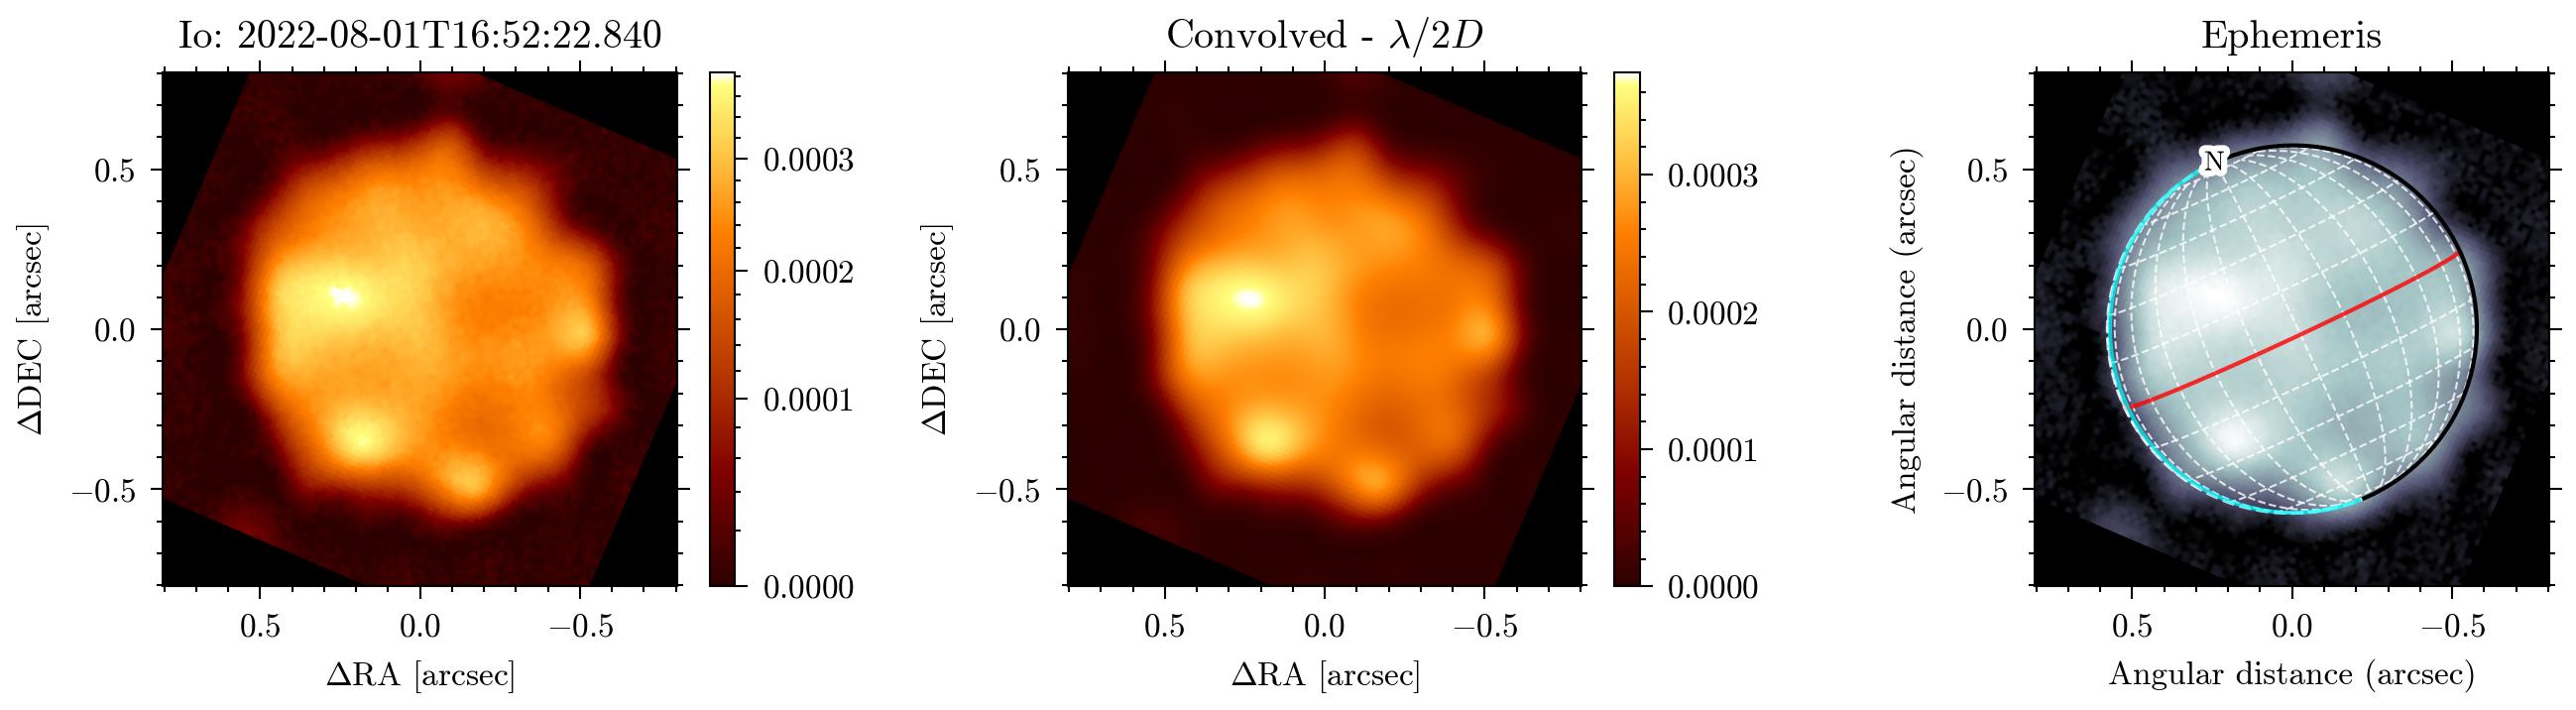

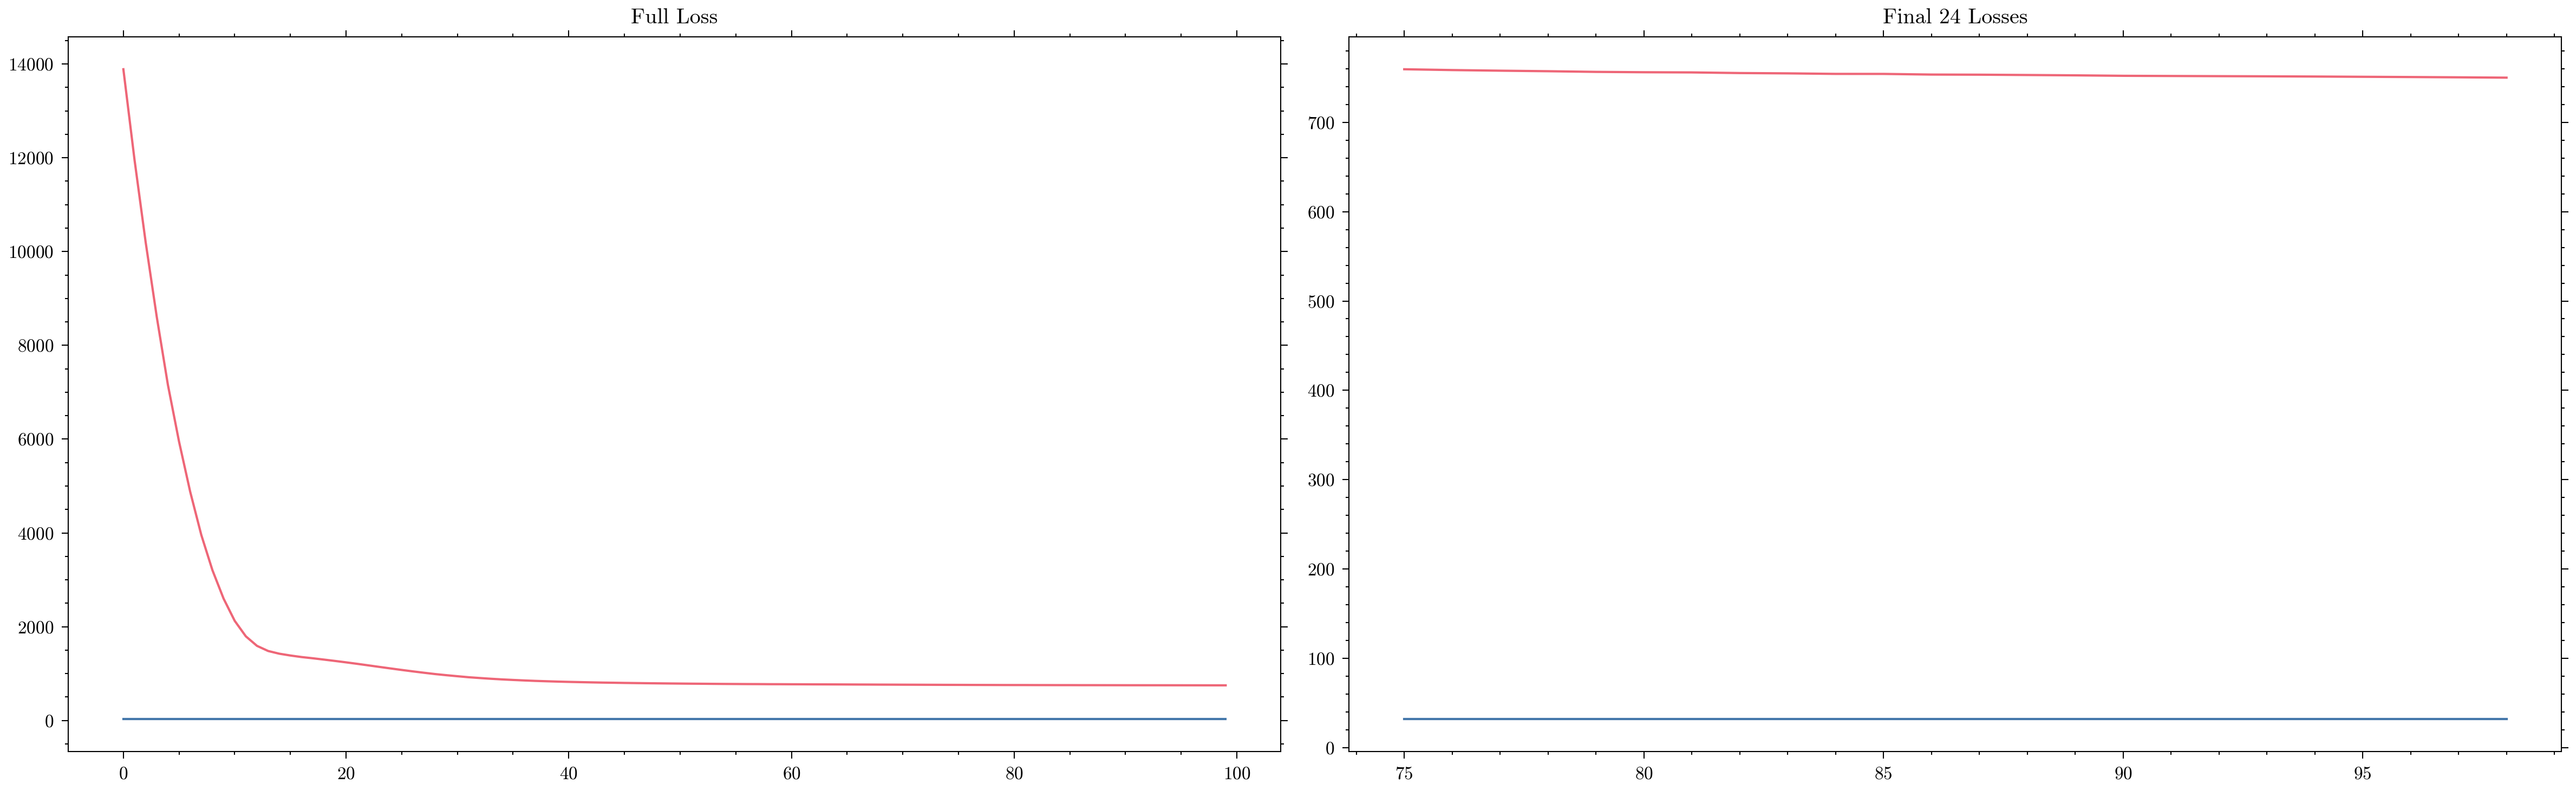

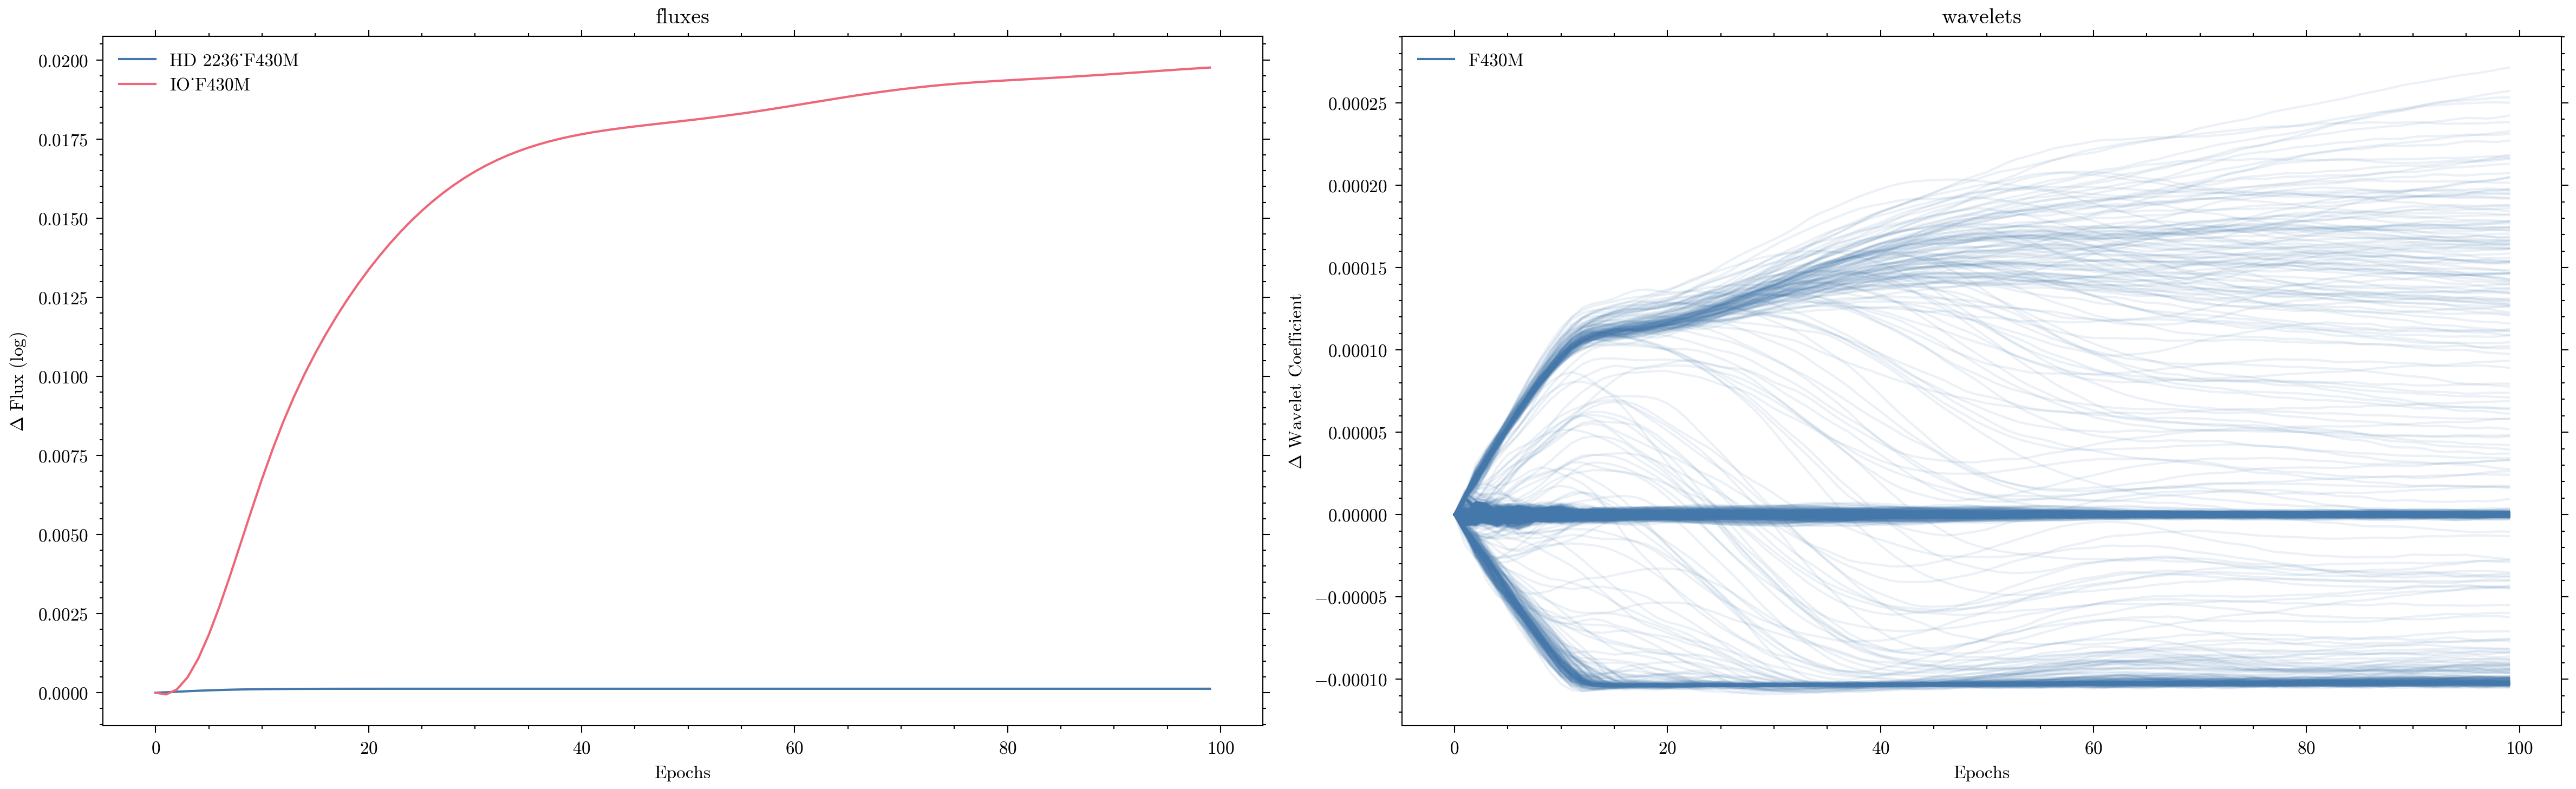

File 01373_023_02_03_1
Star HD 2236
Filter F430M
nints 8
ngroups 12



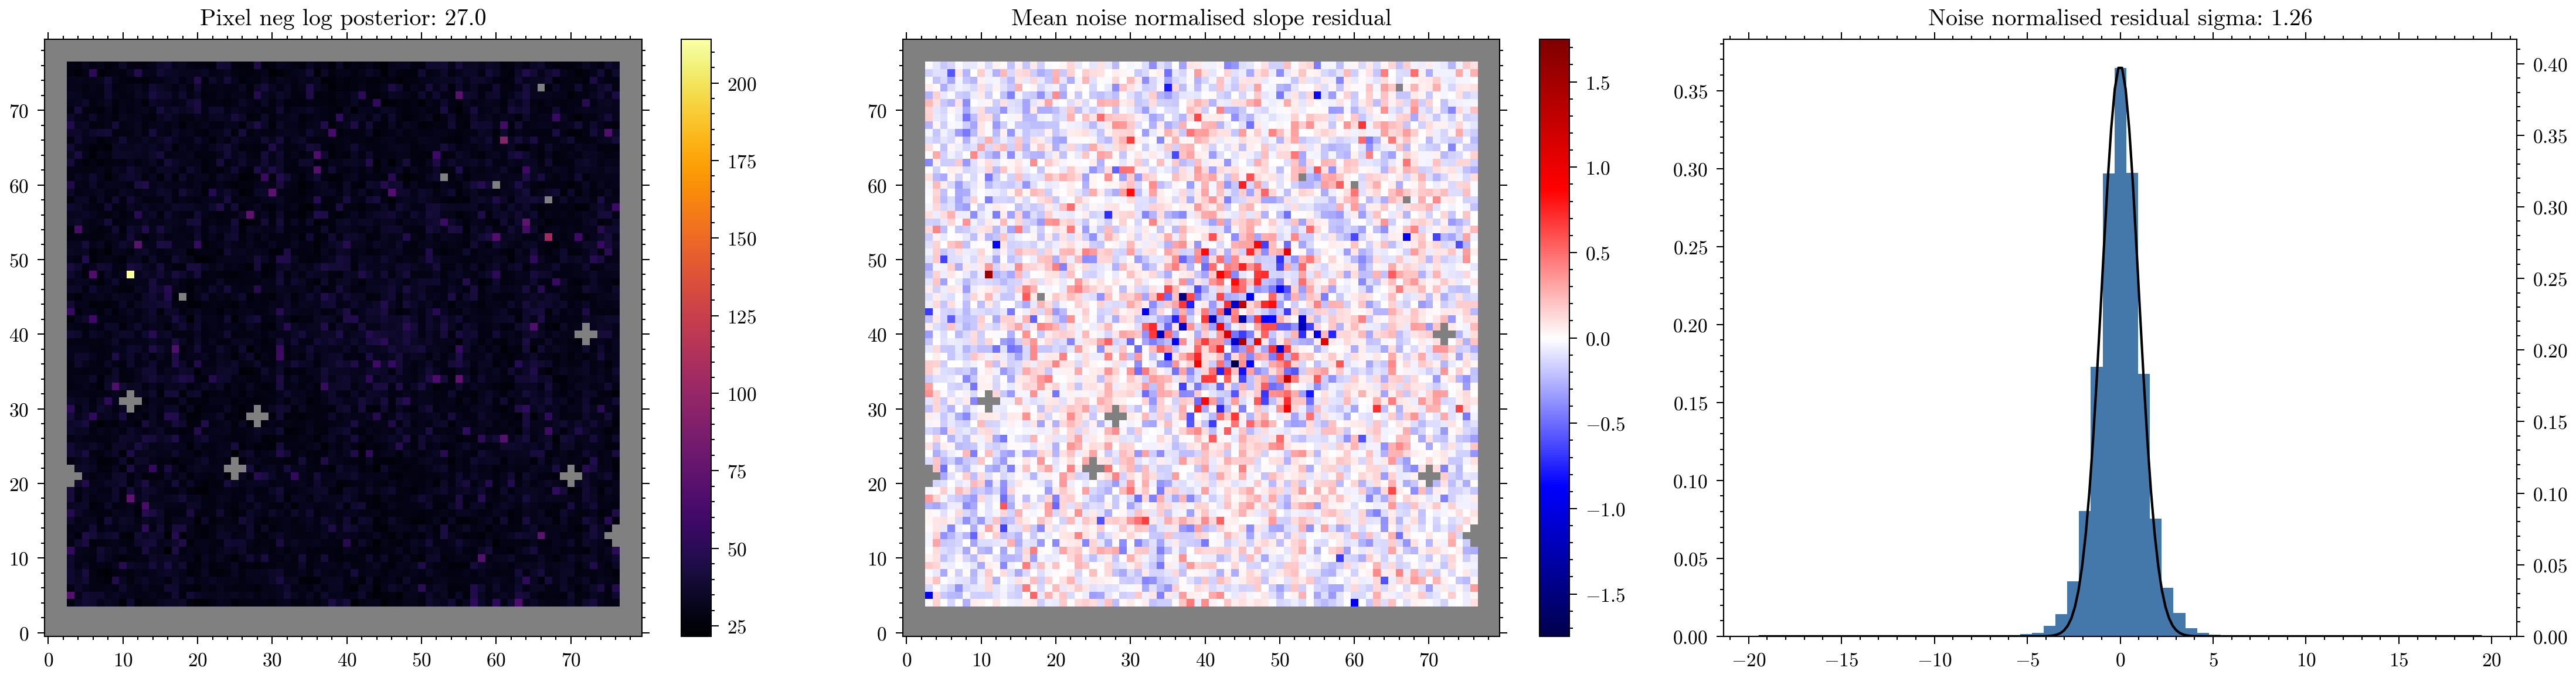

File 01373_017_02_04_3
Star IO
Filter F430M
nints 100
ngroups 18



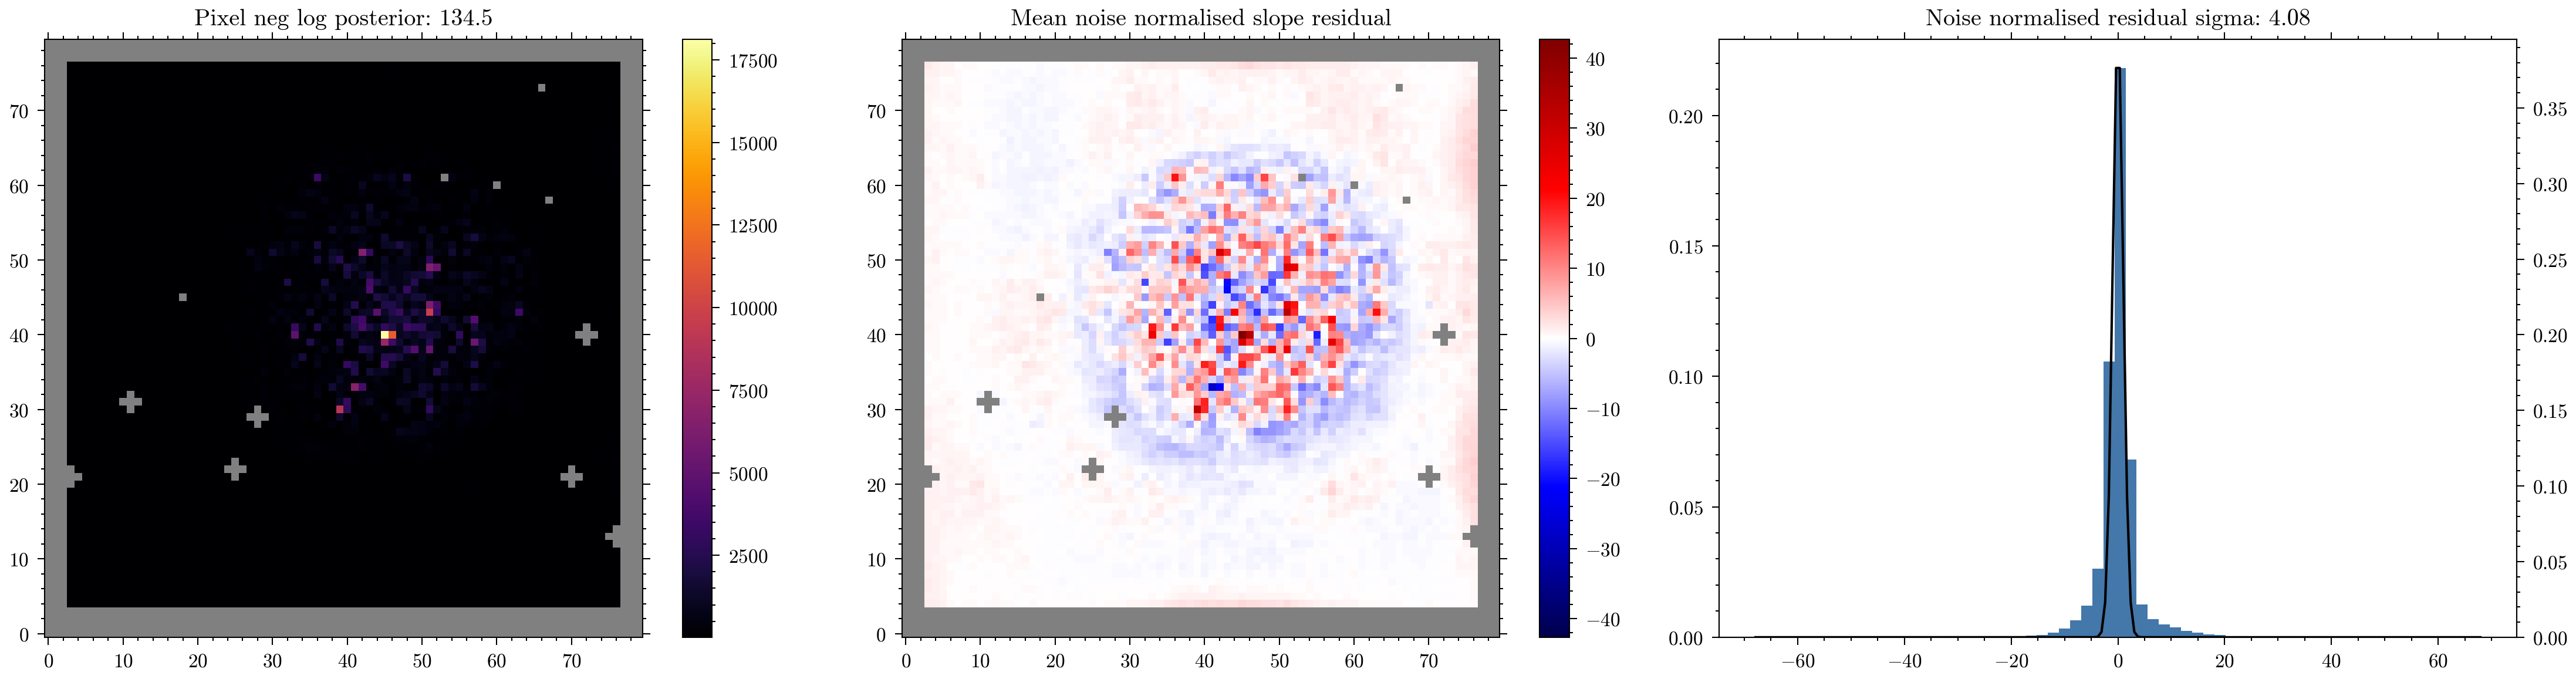

In [ ]:
# io_peak_flux = 10 ** np.array(list(io_final_model.log_distribution.values())).max()

for exp in io_exposures:

    try:
        dist = io_final_model.get_distribution(exp)
    except:
        continue

    time = astropy.time.Time(io_sci_files[0][0].header["EXPMID"], format="mjd").isot
    roll_angle = dorito.plotting.calc_parang(f)

    fig, ax = plt.subplots(1, 3, figsize=(9, 2.5))
    c0 = dorito.plotting.plot_result(
        ax[0],
        dist,
        roll_angle_degrees=-io_rolls[exp.filename],
        cmap="afmhot_10u",
        power=.75,
        vmin=None,
        # vmax=io_peak_flux,
        )
    
    c1 = dorito.plotting.plot_result(
        ax[1],
        dorito.misc.blur_distribution(dist, io_final_model, exp, factor=0.5),
        cmap="afmhot_10u",
        power=1.,
        roll_angle_degrees=-io_rolls[exp.filename],
        # model=hdb_final_model,
        )
    fig.colorbar(c1, ax=ax[1])

    c2 = dorito.plotting.plot_io_with_ephemeris(
        ax[2],
        dist,
        roll_angle_degrees=-io_rolls[exp.filename],
        # n_volc=0,
        cmap="bone_u",
        date=time,
        # vmax=io_peak_flux,
    )

    fig.colorbar(c0)
    ax[0].set_title(f"Io: {time}")
    ax[1].set(title=r"Convolved - $\lambda / 2D$")
    ax[2].set_title(f"Ephemeris")
    plt.tight_layout()
    # plt.savefig(save_dir + f"{time}.png", dpi=300)
    # plt.close()
    plt.show()

amigo.plotting.plot_losses(io_losses, start=int(n_epoch*0.75))
amigo.plotting.plot(io_histories)

for exp in io_exposures:
    exp.print_summary()
    amigo.plotting.summarise_fit(
        exp,
        io_final_model,
        # test_model,
    )


In [12]:
for exp in io_exposures:
    if exp.calibrator:
        continue

    history = np.array(io_histories[exp.get_key("wavelets")]["wavelets"])

    np.save(reconstructions_dir + f"io_shearlet/{exp.get_key('wavelets')}_100_L1_2scls.npy", history)

    for i, wavalues in enumerate(history):

        waveleaves = [
            jax.lax.dynamic_slice(wavalues, (start,), (size,)).reshape(shape)
            for start, size, shape in zip(io_final_model.starts, io_final_model.sizes, io_final_model.shapes)
        ]
        wavelets = jtu.unflatten(io_final_model.tree_def, waveleaves)

        dist = jsl.SLshearrec2D(wavelets, io_final_model.shearletSystem)

        # dist = jaxwt.waverec2(wavelets, io_final_model.wavelet)[0]

        fig, ax = plt.subplots(1, 2, figsize=(6, 2), sharey=True)
        ax[0].set(title=f"{exp.filter}, iter {i}")

        im = dorito.plotting.plot_result(
            ax[0],
            dist,
            cmap="afmhot_10u",
            power=1.,
            roll_angle_degrees=-io_rolls[exp.filename],
            # model=hdb_final_model,
            )
        fig.colorbar(im, ax=ax[0])

        ax[1].set(title=r"Convolved - $\lambda / 2D$")
        im = dorito.plotting.plot_result(
            ax[1],
            dorito.misc.blur_distribution(dist, io_final_model, exp, factor=0.5),
            cmap="afmhot_10u",
            power=1.,
            roll_angle_degrees=-io_rolls[exp.filename],
            # model=hdb_final_model,
            )
        fig.colorbar(im, ax=ax[1])

        # plt.tight_layout()
        plt.savefig(gif_dir + f"io_shearlet/{exp.filter}_{i:04d}.png", dpi=400)
        plt.close()
        # plt.show()


In [13]:
dorito.plotting.create_gif_from_dir(gif_dir + "io_shearlet/", "100_L1_2scls.gif", duration=5, loop=1)

# Gradient CLEAN

In [5]:
import imageio.v3 as iio
from dLux import utils as dlu
import zodiax as zdx
from jax import Array

In [6]:
class CleanFit(dorito.model_fits.DynamicResolvedFit):

    def get_raw_distribution(self, model, exposure) -> Array:
        """
        Returns the normalised intensity distribution of the source.
        """
        distribution = 10 ** model.log_distribution[self.get_key(exposure, "log_distribution")]
        return distribution  # not normalised

    def __call__(self, model, exposure):
        psf = self.model_psf(model, exposure)

        # dealing with unnormalised distribution
        dist = 10 ** model.params["log_distribution"][exposure.get_key("log_distribution")]
        
        # setting next pixel
        pix_idx = model.params["pix_idx"][exposure.get_key("log_distribution")]
        pix_val = model.params["pix_val"][exposure.get_key("log_distribution")]

        print(dist)
        print(pix_idx)
        print(pix_val)
        dist = dist.at[pix_idx].set(pix_val)

        # dealing with flux
        flux = np.log10(dist.sum())  # getting flux
        model = model.set(exposure.map_param('fluxes'), flux)

        # carrying on
        image = psf.convolve(dist / flux)
        image = self.model_detector(image, model, exposure)
        ramp = self.model_ramp(image, model, exposure)
        return self.model_read(ramp, model, exposure)
    

    def get_key(self, exposure, param):
        match param:
            case "pix_idx":
                return "_".join([exposure.key, exposure.filter])
            case "pix_val":
                return "_".join([exposure.key, exposure.filter])
            
        return super().get_key(exposure, param)


    def map_param(self, exposure, param):
        match param:
            case "pix_idx":
                return f"{param}.{exposure.get_key(param)}"
            case "pix_val":
                return f"{param}.{exposure.get_key(param)}"

        return super().map_param(exposure, param)
    

In [7]:
from dorito import model_fits, models, misc

def build_resolved_model(
    cal_files,
    sci_files,
    final_state,
    width: int = None,
    depth: int = None,
    source_size: int = 100,  # in oversampled pixels
    log_dist_prior: Array = None,
    spectral_coeffs_prior=np.array([1.0, 0.0]),
    separate_exposures: bool = False,
    ramp_model=None,
    cal_fit=None,
    sci_fit=None,
    optics=None,
):
    """
    Constructing the model.
    """

    if log_dist_prior is not None:
        if log_dist_prior.shape[0] is not source_size:
            raise ValueError("log_dist_prior must have the same shape as source_size")
    else:
        log_dist_prior = np.log10(np.ones((source_size, source_size)) / source_size**2)

    if ramp_model is None:
        if width is None or depth is None:
            raise ValueError("If ramp_model is not provided, width and depth must be specified")

    if ramp_model is not None and (width is not None or depth is not None):
        raise ValueError("If ramp_model is provided, width and depth must not be specified")

    # Ramp
    if ramp_model is None:
        layers, pooling_layer = amigo.ramp_models.build_pooled_layers(
            width=width,
            depth=depth,
            pooling="avg",
        )
        ramp_model = amigo.ramp_models.MinimalConv(layers, pooling_layer)

    if cal_fit is None:
        cal_fit = amigo.model_fits.PointFit()

    if sci_fit is None:
        sci_fit = model_fits.DynamicResolvedFit()

    if optics is None:
        optics = amigo.core_models.AMIOptics()

    # Setting up calibrator model
    cal_fit = amigo.model_fits.PointFit()
    cal_exposures = [amigo.core_models.Exposure(file, cal_fit) for file in cal_files]
    cal_params = amigo.files.initialise_params(cal_exposures, optics)
    cal_params["Teffs"] = amigo.search_Teffs.get_Teffs(cal_files)

    # Setting up science model
    sci_exposures = [amigo.core_models.Exposure(file, sci_fit) for file in sci_files]
    sci_params = amigo.files.initialise_params(sci_exposures, optics)

    # Setting priors for log distribution and spectral coefficients
    log_distributions = {}
    spectral_coeffs = {}
    pix_idxs = {}
    pix_vals = {}
    for exp in sci_exposures:
        dist_key = exp.get_key("log_distribution")
        log_distributions[dist_key] = log_dist_prior

        spec_key = exp.get_key("spectral_coeffs")
        spectral_coeffs[spec_key] = spectral_coeffs_prior

        pix_idx_key = exp.get_key("pix_idx")
        pix_idxs[pix_idx_key] = np.array([0, 0], dtype=int)

        pix_val_key = exp.get_key("pix_val")
        pix_vals[pix_val_key] = np.array(3.e1, dtype=float)

    sci_params["log_distribution"] = log_distributions
    sci_params["spectral_coeffs"] = spectral_coeffs
    sci_params["pix_idx"] = pix_idxs
    sci_params["pix_val"] = pix_vals

    # combining calibrator and science
    params = misc.combine_param_dicts(cal_params, sci_params)

    # setting up filters
    filters = {}
    for filt in list(set([exp.filter for exp in [*sci_exposures, *cal_exposures]])):
        filters[filt] = amigo.misc.calc_throughput(filt, nwavels=9)

    model = models.ResolvedAmigoModel(
        params,
        optics=optics,
        ramp=ramp_model,
        detector=amigo.core_models.LinearDetectorModel(),
        read=amigo.read_models.ReadModel(),
        filters=filters,
    )
    model = amigo.misc.populate_from_state(model, final_state)

    if separate_exposures:
        return model, params, cal_exposures, sci_exposures
    else:
        exposures = [*cal_exposures, *sci_exposures]
        return model, params, exposures

In [8]:
io_model, io_params, io_cal_exposures, io_sci_exposures = build_resolved_model(
    [io_cal_files[-1]],
    [io_sci_files[-1]],
    # pds_cal_files,
    # pds_sci_files,
    final_state,
    source_size=101,
    sci_fit=CleanFit(),
    width=width,
    depth=depth,
    separate_exposures=True,
    log_dist_prior=np.log10(1e-3 * np.ones((101, 101))),
)

# io_exposures = [*io_cal_exposures, *io_sci_exposures]
io_model = io_model.set("FF", np.ones_like(io_model.FF))

io_init_state = np.load(init_state_cache + "io/io_setup.npy", allow_pickle=True)[()]

for p in ["positions", "fluxes", "aberrations"]:
    io_params[p] = io_init_state[p]

io_model = io_model.set("params", io_params)

In [9]:
# import jax.numpy as jnp
# from jax import jit



# # Example 2D array (101, 101)
# array = jnp.zeros((101, 101))

# # Pixel index obtained from np.unravel_index
# pixel_index = np.unravel_index(np.argmax(dist), dist.shape)  # Replace this with your actual pixel index

# # Value to set at the pixel index
# new_value = 42.0

# # Function to update array at pixel_index
# @jit
# def set_pixel_value(array, pixel_index, new_value):
#     return array.at[pixel_index].set(new_value)

# # Update the array
# updated_array = set_pixel_value(array, pixel_index, new_value)

# plt.imshow(updated_array)

In [10]:
# plt.subplots(1, 2)

# x = np.where(io_sci_exposures[0].badpix, np.nan, io_sci_exposures[0].slopes.mean(0))
# v = np.nanmax(x)
# plt.subplot(1, 2, 1)
# plt.imshow(x, vmax=v)
# plt.colorbar()

# plt.subplot(1, 2, 2)
# plt.imshow(io_model.model(io_sci_exposures[0]).mean(0), vmax=v)
# plt.colorbar()

# plt.show()

In [11]:
# sphere_path = "/Users/mcha5804/Library/CloudStorage/OneDrive-TheUniversityofSydney(Students)/PyCharm/jwst/io/sphere.jpg"
# im = iio.imread(sphere_path).mean(2)


# residual_map = psf.convolve(dlu.downsample(im, 4))

In [12]:
# def loss_fn(model, exposure, args={}):
#     return -0.5 * np.nansum((exposure.slopes - model.model(exposure))**2 / exposure.variance)

grad_fn = zdx.filter_grad(["log_distribution"])(amigo.stats.reg_loss_fn)
grad_fn = zdx.filter_jit(grad_fn)


Want to create a latent array thing -- do gradient descent on a pixel

In [13]:

def update_pixel(model, exposures):
    """
    Update a pixel in the log distribution.
    """

    new_log_dists = {}

    for exp in exposures:
        exp_key = exp.get_key("log_distribution")
        idx = model.params["pix_idx"][exp_key]
        val = model.params["pix_val"][exp_key]

        # dist = 10 ** model.params["log_distribution"][exp_key]
        # bool_array = np.zeros_like(dist, dtype=bool).at[idx].set(True)
        new_log_dist = np.log10(dist.at[idx].set(val))
        new_log_dists[exp_key] = new_log_dist

    return model.set(f"log_distribution", new_log_dists)



In [ ]:
model = io_model
exposure = io_sci_exposures[0]

# plt.imshow(model.get("log_distribution")[exposure.get_key("log_distribution")])
grads = grad_fn(model, exposure, args={}).get("log_distribution")[exposure.get_key("log_distribution")]
max_idx = np.unravel_index(np.argmin(grads), grads.shape)  # TODO argmax?
print(max_idx)

v = np.max(np.abs(grads))
plt.figure(figsize=(2, 1))
plt.imshow(grads, seismic, vmin=-v, vmax=v)
plt.colorbar()
plt.axis("off")
plt.show()

In [ ]:
fisher_params = ["pix_val"]

fishers = amigo.fisher.calc_fishers(
    io_model.set("ramp", None),
    io_sci_exposures,
    fisher_params,
    # recalculate=True,
    )

In [ ]:
model = io_model
epochs = 6

optims = {
    "pix_val": sgd(1e-6, 0),
}

for i in range(1):
    grads = grad_fn(model, exposure, args={}).get("log_distribution")[exposure.get_key("log_distribution")]
    max_idx = np.unravel_index(np.argmin(grads), grads.shape)
    model = model.set(f"pix_idx.{exposure.get_key('pix_idx')}", max_idx)

    model, losses, _, history = amigo.fitting.optimise(
        model,
        [exposure],
        optims,
        epochs=epochs,
        fishers=fishers,
    )

    dist = 10 ** model.get("log_distribution")[exposure.get_key("log_distribution")]
    plt.imshow(dist)
    plt.colorbar()
    plt.show()
    model = update_pixel(model, [exposure])

    dist = 10 ** model.get("log_distribution")[exposure.get_key("log_distribution")]
    plt.imshow(dist)
    plt.colorbar()
    plt.show()

    amigo.plotting.plot_losses(losses, int(epochs*0.75))
    amigo.plotting.plot(history)

    # gain_array = np.zeros_like(dist).at[max_idx].set(gain)
    # new_dist = dist + gain_array
    # # new_dist /= new_dist.sum()

    # model = model.set(f"log_distribution.{exposure.get_key('log_distribution')}", np.log10(new_dist))

    plt.subplots(1, 2, figsize=(3, 1))

    plt.subplot(1, 2, 1)
    plt.imshow(dist, inferno, norm=mpl.colors.PowerNorm(0.5, vmin=0))
    plt.colorbar()
    plt.axis("off")

    v = np.max(np.abs(grads))
    plt.subplot(1, 2, 2)
    plt.imshow(grads, seismic, vmin=-v, vmax=v)
    plt.colorbar()
    plt.axis("off")

    plt.show()

In [ ]:
v = np.max(np.abs(grads))

plt.imshow(grads, seismic, vmin=-v, vmax=v)
plt.colorbar()
plt.show()

dist = 10 ** model.get("log_distribution")[exposure.get_key("log_distribution")]
v = np.max(np.abs(dist))
plt.imshow(dist, seismic, vmin=-v, vmax=v)
plt.colorbar()
plt.show()